<a href="https://colab.research.google.com/github/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/t042_molt5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MolT5 — 분자와 자연어 사이를 번역하는 모델

**Day 06 · LLM 활용 & 신약개발 실습**

분자 설명문(자연어)과 SMILES(분자 구조 문자열)를 **양방향으로 번역**하는 MolT5를 직접 돌려 보고,
같은 문제를 2022·2024·2026년 세 세대의 모델에 던져 **무엇이 달라졌는지**를 한 화면에서 비교한다.


## 0. 실행 환경

- **Colab에서 바로 실행됩니다.** GPU(T4)를 켜면 빠르지만, **CPU 런타임에서도 동작**합니다.
- 이 노트북은 `molt5-large` 모델 **2종(caption2smiles, smiles2caption)** 을 내려받습니다. 각각 약 3GB이므로
  첫 실행 시 다운로드에 수 분이 걸립니다. Hugging Face 로그인이나 라이선스 동의는 **필요 없습니다**.
- 생성 시간(참고): CPU 기준 프롬프트 1개당 약 15초, GPU에서는 1~2초.
- 9절의 세대 비교에는 **선택 실행 경로**가 세 개 있습니다. 없으면 **자동으로 건너뜁니다(에러 없음)**.
  - 세대 ② `ChemDFM-8B` — GPU 필요 (약 16 GB 다운로드)
  - 세대 ③-A `Gemini` — API 키 필요 (무료 티어, 다운로드 없음)
  - 세대 ③-B `ChemVLM-8B` — GPU 필요 (약 16 GB 다운로드)
- 아래 셀이 필요한 패키지를 먼저 확인해 **없는 것만** 설치하고, 연산 장치를 `DEVICE` 상수 하나로 고정합니다.
  이후 모든 셀은 `DEVICE` 만 참조합니다.


In [1]:

import importlib, subprocess, sys

REQUIRED = {
    # "import 이름": "pip 패키지명"
    "transformers": "transformers",      # T5 계열 모델/토크나이저
    "rdkit": "rdkit",                    # SMILES 파싱 및 분자 그림
    "sentencepiece": "sentencepiece",    # T5Tokenizer 가 요구하는 토크나이저 백엔드
    "matplotlib": "matplotlib",          # 9절 비교 차트
}

def ensure(packages: dict) -> list:
    """import 가능한지 먼저 확인하고, 없는 것만 pip로 설치한다."""
    missing = [pip_name for mod, pip_name in packages.items()
               if importlib.util.find_spec(mod) is None]
    if missing:
        print("설치 대상:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    else:
        print("모든 의존 패키지가 이미 준비되어 있습니다.")
    return missing

ensure(REQUIRED)


import torch

# 연산 장치는 이 상수 하나로 고정한다 (노트북 전체에서 DEVICE 만 사용)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("DEVICE =", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM: %.1f GB" % (torch.cuda.get_device_properties(0).total_memory / 1024 ** 3))
else:
    print("[안내] CPU 런타임입니다. 실행은 되지만 molt5-large 생성이 프롬프트당 약 15초로 느려지고,")
    print("       9절의 8B 모델(ChemDFM · ChemVLM)은 GPU가 없으므로 자동으로 건너뜁니다.")

# --- sentencepiece 버전 고정 (ChemVLM/InternLM2 토크나이저 호환) ---
# sentencepiece 0.2.x 는 InternLM2 의 tokenizer.model 을 거부한다
# (RuntimeError: piece must not include null character).
# 0.1.99 는 MolT5(T5Tokenizer, vocab 32,100)와 ChemVLM(InternLM2, vocab 92,553)
# 양쪽 모두에서 정상 동작함을 확인했다. 9절 멀티모달을 쓰려면 이 셀을 먼저 실행한다.
def pin_sentencepiece(target: str = "0.1.99") -> bool:
    """설치된 sentencepiece 가 0.2 이상이면 target 으로 내리고 재시작이 필요한지 알려준다."""
    try:
        import sentencepiece
        cur = sentencepiece.__version__
    except Exception:
        cur = None
    if cur is not None and not cur.startswith("0.2"):
        print(f"[sentencepiece] {cur} — 그대로 사용합니다.")
        return False
    print(f"[sentencepiece] 현재 {cur} → {target} 로 교체합니다 (ChemVLM 토크나이저 호환).")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", f"sentencepiece=={target}"], check=False)
    if cur is None:
        return False
    print("=" * 72)
    print("[재시작 필요] sentencepiece 가 이미 로드돼 있어 런타임을 다시 시작해야 적용됩니다.")
    print("  Colab: 상단 메뉴 [런타임] > [세션 다시 시작] 후 이 노트북을 처음부터 다시 실행하세요.")
    print("  (9절 멀티모달을 쓰지 않는다면 무시하고 계속 진행해도 됩니다.)")
    print("=" * 72)
    return True

SP_RESTART_NEEDED = pin_sentencepiece()


모든 의존 패키지가 이미 준비되어 있습니다.
PyTorch: 2.11.0+cu128
DEVICE = cuda
GPU: Tesla T4
VRAM: 14.6 GB
[sentencepiece] 0.1.99 — 그대로 사용합니다.


## 1. 개요와 학습 목표

MolT5는 T5 (Text-To-Text Transfer Transformer) 아키텍처를 기반으로 한 분자 언어모델로, 다양한 화학정보학(Cheminformatics) 작업을 처리하기 위해 설계되었습니다. 이 모델은 분자 설명을 SMILES(분자 구조를 표현하는 문자열 형식), IUPAC 이름, 분자 특성 등의 다양한 표현으로 변환할 수 있습니다. MolT5는 화학 언어와 구조화된 분자 데이터 간의 복잡한 매핑을 학습하는 능력 덕분에 신약 개발과 화학정보학 분야에서 중요한 도구로 활용될 수 있습니다.

MolT5의 원 논문은 Edwards et al., **"Translation between Molecules and Natural Language"** (EMNLP 2022, arXiv:2204.11817) 입니다.
대량의 무표지(unlabeled) SMILES와 텍스트로 T5를 사전학습한 뒤, ChEBI-20 데이터셋으로
**molecule captioning(분자 → 설명)** 과 **text-based de novo molecule generation(설명 → 분자)** 두 과제를 미세조정한 모델입니다.
공개 체크포인트가 `laituan245/molt5-*` 이며, 이 노트북에서는 그 중 `-large` 두 종을 사용합니다.

> ⚠️ 이 노트북의 이전 버전에는 실제로 존재하지 않는 논문 제목이 인용되어 있었습니다.
> 생성형 모델 실습에서는 **모델 출력뿐 아니라 교재의 인용도 검증 대상**이라는 점을 기억하세요.

### 학습 목표

- **설명 → SMILES** 방향으로 분자를 생성하고, 생성된 문자열을 **RDKit 파싱으로 반드시 검증**한다 (4-6절).
- **SMILES → 설명** 방향으로 캡션을 만들고, 그 설명이 실제 약리작용과 어긋날 수 있음을 확인한다 (7-8절).
- 태스크마다 **별도 체크포인트**가 필요한 전용 번역기의 구조적 제약을 체감한다.
- **구조 이미지를 입력**으로 주고 SMILES를 되받는 **왕복 검증**으로, 세대 ③이 새로 얻은 능력을 확인한다 (9-5절).
- 같은 문제를 세 세대(전용 번역기 → 화학 지시학습 LLM → 멀티모달/프론티어)에 던져
  **기계적 지표(유효성 · canonical 일치 · Tanimoto · 키워드 적중)** 로만 비교한다 (9절).
- n=1 시연과 벤치마크의 차이를 구분하고, 결과를 과장하지 않는 서술 방식을 익힌다.

## 2. 라이브러리 가져오기

In [2]:
# 필요한 라이브러리 가져오기
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration
from rdkit.Chem import Draw
from rdkit import Chem
import pandas as pd  # 여러 분자 설명을 처리하기 위한 라이브러리
from IPython.display import display  # Colab에서 이미지를 표시하기 위한 라이브러리

# 연산 장치는 0절에서 정의한 DEVICE 상수를 그대로 쓴다 (재정의하지 않는다)
print("DEVICE =", DEVICE)

DEVICE = cuda


## 3. MolT5 모델과 토크나이저 로드하기

In [3]:
# MolT5 모델과 토크나이저 로드
# molt5-large 는 약 3GB 입니다. 첫 실행 시 다운로드에 수 분 걸릴 수 있습니다.
tokenizer = T5Tokenizer.from_pretrained("laituan245/molt5-large-caption2smiles", model_max_length=512)
model = T5ForConditionalGeneration.from_pretrained("laituan245/molt5-large-caption2smiles").to(DEVICE).eval()
print("caption2smiles 모델 로드 완료 (DEVICE =", DEVICE, ")")

Loading weights:   0%|          | 0/560 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


caption2smiles 모델 로드 완료 (DEVICE = cuda )


## 4. 하나의 텍스트 설명을 분자로 변환하기

생성된 SMILES: CC(C)(C)C1=CC=C(C=C1)CC(C)(C)NCC(C2=CC(=C(C=C2)F)F)O
RDKit 파싱 성공 - 유효한 SMILES 입니다. Canonical: CC(C)(Cc1ccc(C(C)(C)C)cc1)NCC(O)c1ccc(F)c(F)c1


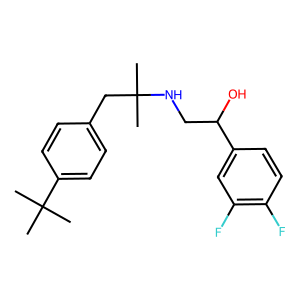

In [4]:
# 분자에 대한 텍스트 설명 입력 (PDE5 저해제 예시: 실데나필/sildenafil)
input_text = 'The molecule is sildenafil, a selective phosphodiesterase type 5 (PDE5) inhibitor used to treat erectile dysfunction and pulmonary arterial hypertension.'

# 설명을 SMILES로 변환
inputs = tokenizer.encode(input_text, return_tensors="pt").to(DEVICE)
output_ids = model.generate(inputs, max_length=512)
smiles = tokenizer.decode(output_ids[0], skip_special_tokens=True)
print("생성된 SMILES:", smiles)

# RDKit 파싱으로 유효성 검사 후 시각화
mol = Chem.MolFromSmiles(smiles)
if mol:
    print("RDKit 파싱 성공 - 유효한 SMILES 입니다. Canonical:", Chem.MolToSmiles(mol))
    display(Draw.MolToImage(mol, size=(300, 300)))
else:
    print("유효한 분자를 생성할 수 없습니다 (RDKit 파싱 실패).")

# [9절 '세 세대 비교'에서 재사용] 이 셀의 결과를 별도 변수에 보관 (아래 6절에서 smiles 가 덮어써지므로)
MOLT5_CAPTION2SMILES_OUT = smiles

> **모델의 한계에 대한 안내**
>
> MolT5는 "설명 → SMILES"를 학습한 모델일 뿐, 화합물 데이터베이스를 조회하는 것이 아닙니다.
> 따라서 "sildenafil" 이라고 이름을 주어도 **실제 실데나필 구조가 나오지 않는 경우가 대부분**입니다.
> 이 실습의 목적은 정답 구조를 얻는 것이 아니라, (1) 생성 모델이 화학 문자열을 만들어낸다는 점과
> (2) **생성 결과는 반드시 RDKit 파싱으로 검증해야 한다**는 점을 확인하는 것입니다.
> 실제 구조는 아래 7절에서 정답 SMILES를 직접 넣어 확인합니다.

## 5. 여러 개의 분자 설명을 일괄 처리

,Description,SMILES,Valid,Canonical
0,A benzene ring substituted with a nitro group ...,C1=CC=C(C(=C1)[N+](=O)[O-])O,True,O=[N+]([O-])c1ccccc1O
1,A molecule consisting of a six-membered ring w...,C1=CC(=C(C=C1O)O)O,True,Oc1ccc(O)c(O)c1
2,An aliphatic compound containing a methyl grou...,CCC(C)(C)C,True,CCC(C)(C)C


유효 SMILES: 3 / 3


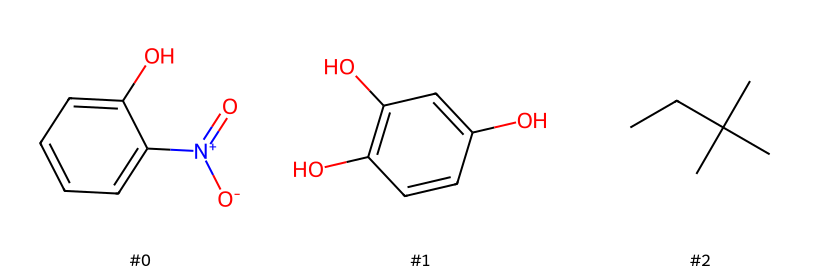

In [5]:
# 여러 개의 분자 설명 예시
descriptions = [
    'A benzene ring substituted with a nitro group at position 1 and a hydroxyl group at position 2.',
    'A molecule consisting of a six-membered ring with two hydroxyl groups at positions 1 and 3.',
    'An aliphatic compound containing a methyl group at the first carbon and an ethyl group at the second carbon.'
]

# 여러 설명을 처리하기 위한 DataFrame 생성
df = pd.DataFrame(descriptions, columns=['Description'])
df['SMILES'] = ''

# 각 설명에 대해 SMILES 생성
for idx, desc in enumerate(df['Description']):
    inputs = tokenizer.encode(desc, return_tensors="pt").to(DEVICE)
    output_ids = model.generate(inputs, max_length=512)
    df.at[idx, 'SMILES'] = tokenizer.decode(output_ids[0], skip_special_tokens=True)

# 생성된 SMILES 전부에 대해 RDKit 파싱 유효성 검사
df['Valid'] = [Chem.MolFromSmiles(s) is not None for s in df['SMILES']]
df['Canonical'] = [Chem.MolToSmiles(Chem.MolFromSmiles(s)) if Chem.MolFromSmiles(s) else None
                   for s in df['SMILES']]

# DataFrame 표시
display(df)
print(f"유효 SMILES: {int(df['Valid'].sum())} / {len(df)}")

# 유효한 분자만 그리드로 시각화
valid_mols = [Chem.MolFromSmiles(s) for s, v in zip(df['SMILES'], df['Valid']) if v]
if valid_mols:
    display(Draw.MolsToGridImage(valid_mols,
                                 legends=[f"#{i}" for i, v in enumerate(df['Valid']) if v],
                                 molsPerRow=3, subImgSize=(280, 280)))

## 6. 에러 처리 및 시각화

생성된 SMILES: [H+].[H+].CC1=CC=C(C=C1)N
RDKit 파싱 성공: Cc1ccc(N)cc1.[H+].[H+]


[13:43:22] WARNING: not removing hydrogen atom without neighbors
[13:43:22] WARNING: not removing hydrogen atom without neighbors


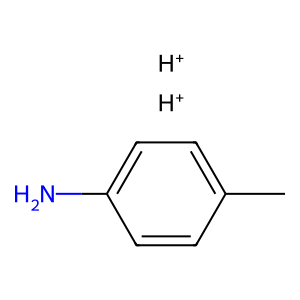

In [6]:
# 분자를 시각화하는 함수 (RDKit 파싱 유효성 검사 포함)
def visualize_molecule(smiles):
    """SMILES를 RDKit으로 파싱해 유효하면 2D 구조를 그린다."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            print("RDKit 파싱 성공:", Chem.MolToSmiles(mol))
            display(Draw.MolToImage(mol, size=(300, 300)))
        else:
            print(f"유효하지 않은 SMILES: {smiles}")
    except Exception as e:
        print(f"오류: {e}")

# 에러 처리가 포함된 예시 (의도적으로 모호한 설명을 넣습니다)
input_text = 'A molecule with an invalid description.'
inputs = tokenizer.encode(input_text, return_tensors="pt").to(DEVICE)
output_ids = model.generate(inputs, max_length=512)
smiles = tokenizer.decode(output_ids[0], skip_special_tokens=True)
print("생성된 SMILES:", smiles)

# 에러 처리를 포함한 시각화
visualize_molecule(smiles)

## 7. SMILES를 설명으로 변환하기

Loading weights:   0%|          | 0/560 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


입력 SMILES 유효성: True


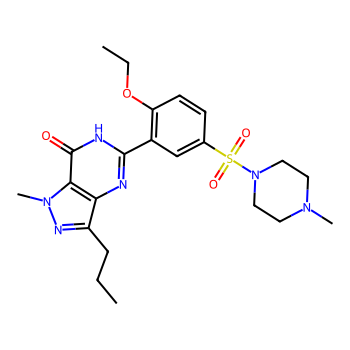

생성된 설명: The molecule is a member of the class of pyrazoles that is 1H-pyrazole which is substituted at positions 1, 3, and 5 by ethyl, sulfamoyl, and cyclohexyl groups, respectively. A selective cyclooxygenase 2 inhibitor, it is used in veterinary medicine to treat pain and inflammation in dogs with degenerative joint disease. It has a role as a non-steroidal anti-inflammatory drug, a cyclooxygenase 2 inhibitor and a non-narcotic analgesic. It is a member of pyrazoles, an organic sulfide and a sulfonamide.

[안내] MolT5가 만든 설명이 실제 실데나필 약리작용과 다를 수 있습니다.
       생성형 모델의 설명은 근거 문헌으로 반드시 교차검증해야 합니다.


In [7]:
# SMILES를 설명으로 변환하기 위한 모델 로드 (약 3GB, 첫 실행 시 다운로드)
tokenizer_caption = T5Tokenizer.from_pretrained("laituan245/molt5-large-smiles2caption", model_max_length=512)
model_caption = T5ForConditionalGeneration.from_pretrained("laituan245/molt5-large-smiles2caption").to(DEVICE).eval()

# 예시 SMILES 문자열 - 실데나필(비아그라)
smiles_example = "CCCc1nn(C)c2c1nc([nH]c2=O)-c1cc(ccc1OCC)S(=O)(=O)N1CCN(C)CC1"

# 입력 SMILES 자체가 유효한지 먼저 RDKit으로 확인
mol_example = Chem.MolFromSmiles(smiles_example)
print("입력 SMILES 유효성:", mol_example is not None)
display(Draw.MolToImage(mol_example, size=(350, 350)))

inputs = tokenizer_caption.encode(smiles_example, return_tensors="pt").to(DEVICE)
output_ids = model_caption.generate(inputs, max_length=512)
description = tokenizer_caption.decode(output_ids[0], skip_special_tokens=True)

print("생성된 설명:", description)
print()
print("[안내] MolT5가 만든 설명이 실제 실데나필 약리작용과 다를 수 있습니다.")
print("       생성형 모델의 설명은 근거 문헌으로 반드시 교차검증해야 합니다.")

## 8. SMILES 문자열 변형

In [8]:
# 8절에서는 "설명을 바꿔서 유사 구조를 만들어보기"를 해봅니다.
# 먼저 원본 SMILES -> 설명 (smiles2caption)
tokenizer_smiles2caption = tokenizer_caption
model_smiles2caption = model_caption

# 원본 SMILES 예시
original_smiles = "CCCc1nn(C)c2c1nc([nH]c2=O)-c1cc(ccc1OCC)S(=O)(=O)N1CCN(C)CC1"  # 실데나필 (PDE5 저해제)

# SMILES를 설명으로 변환
inputs = tokenizer_smiles2caption.encode(original_smiles, return_tensors="pt").to(DEVICE)
output_ids = model_smiles2caption.generate(inputs, max_length=512)
caption = tokenizer_smiles2caption.decode(output_ids[0], skip_special_tokens=True)

print("SMILES에 대한 설명:", caption)

SMILES에 대한 설명: The molecule is a member of the class of pyrazoles that is 1H-pyrazole which is substituted at positions 1, 3, and 5 by ethyl, sulfamoyl, and cyclohexyl groups, respectively. A selective cyclooxygenase 2 inhibitor, it is used in veterinary medicine to treat pain and inflammation in dogs with degenerative joint disease. It has a role as a non-steroidal anti-inflammatory drug, a cyclooxygenase 2 inhibitor and a non-narcotic analgesic. It is a member of pyrazoles, an organic sulfide and a sulfonamide.


결합된 설명: The molecule is a member of the class of pyrazoles that is 1H-pyrazole which is substituted at positions 1, 3, and 5 by ethyl, sulfamoyl, and cyclohexyl groups, respectively. A selective cyclooxygenase 2 inhibitor, it is used in veterinary medicine to treat pain and inflammation in dogs with degenerative joint disease. It has a role as a non-steroidal anti-inflammatory drug, a cyclooxygenase 2 inhibitor and a non-narcotic analgesic. It is a member of pyrazoles, an organic sulfide and a sulfonamide. In this molecule, the N-methyl group on the piperazine ring is replaced by an ethyl group.
변형된 SMILES: CCC1CCC(CC1)C2=CC(=NN2C3=CC=C(C=C3)S(=O)(=O)N)C
원본 유효: True / 변형 유효: True


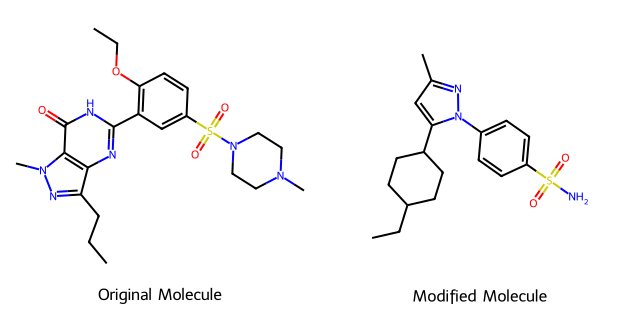

In [9]:
# 변형된 설명 (예: 실데나필의 피페라진 N-메틸기를 에틸기로 치환하는 유사 구조 변형)
modification = "In this molecule, the N-methyl group on the piperazine ring is replaced by an ethyl group."
combined_caption = caption + " " + modification

print("결합된 설명:", combined_caption)

# Caption-to-SMILES 모델은 3절에서 이미 로드했으므로 재사용합니다
tokenizer_caption2smiles = tokenizer
model_caption2smiles = model

# 변형된 설명을 SMILES로 변환
inputs = tokenizer_caption2smiles.encode(combined_caption, return_tensors="pt").to(DEVICE)
output_ids = model_caption2smiles.generate(inputs, max_length=512)
modified_smiles = tokenizer_caption2smiles.decode(output_ids[0], skip_special_tokens=True)

print("변형된 SMILES:", modified_smiles)

# RDKit 파싱 유효성 검사 후 원본과 나란히 시각화
original_mol = Chem.MolFromSmiles(original_smiles)
modified_mol = Chem.MolFromSmiles(modified_smiles)
print("원본 유효:", original_mol is not None, "/ 변형 유효:", modified_mol is not None)

if original_mol and modified_mol:
    img = Draw.MolsToGridImage([original_mol, modified_mol],
                               legends=["Original Molecule", "Modified Molecule"],
                               molsPerRow=2, subImgSize=(320, 320))
    display(img)
else:
    print("원본 또는 변형된 SMILES로부터 유효한 분자를 생성할 수 없습니다.")

## 9. 같은 문제, 세 세대 — 화학 언어모델 3세대 비교

지금까지 본 MolT5는 **2022년의 전용 번역기**입니다. 4절에서 실데나필 설명을 넣었을 때 실데나필이 나오지 않았고,
7절에서 실데나필 SMILES를 넣었을 때 설명도 어긋났습니다. 이건 MolT5가 못 만든 모델이라서가 아니라,
**그 세대의 모델이 할 수 있도록 설계된 일의 범위**가 거기까지였기 때문입니다.

이 절에서는 **완전히 같은 문제 하나**(실데나필, 양방향)를 세 세대의 모델에 똑같이 던져서
무엇이 달라졌는지 직접 확인합니다.

| 세대 | 대표 모델 (실제 Hugging Face ID) | 라이선스 · 크기 | 성격 |
|---|---|---|---|
| **① 전용 번역기 (2022)** | `laituan245/molt5-large-caption2smiles` / `-smiles2caption`<br>(계열: BioT5 `QizhiPei/biot5-base-text2mol`) | Apache-2.0 · 약 3 GB × 2 | T5 encoder-decoder. **태스크 고정**(설명↔SMILES 단방향 번역), 대화 불가, 지시 이해 불가 |
| **② 화학 지시학습 LLM (2024–25)** | `OpenDFM/ChemDFM-v1.5-8B`<br>`AI4Chem/ChemLLM-7B-Chat` | AGPL-3.0 · 16.1 GB (8B)<br>Apache-2.0 · 약 15 GB (7B) | decoder-only LLM에 화학 도메인 사전학습 + 지시학습. **대화·다중 태스크·단계적 추론** 가능 |
| **③ 멀티모달 / 프론티어 (2025–26)** | `AI4Chem/ChemVLM-8B` (image-text-to-text)<br>Gemini · GPT-5 등 상용 프론티어 | Apache-2.0 · 약 16 GB<br>상용 API | 구조 **이미지**를 직접 입력받거나(ChemVLM), 범용 추론력으로 화학 문제를 푸는 초대형 모델 |

**모델 선택에 대한 정직한 고지**

- 위 세 개의 오픈 모델(`ChemDFM-v1.5-8B`, `ChemLLM-7B-Chat`, `ChemVLM-8B`)은 2026-09 기준 **HF에서 공개·비게이팅** 상태임을 실제로 확인했습니다.
- 반면 강의에서 자주 언급되는 **ChemMLLM**, **3D-MoLM** 은 현재 HF 접근이 **게이팅/비공개(HTTP 401)** 라서
  **이 노트북에서 실습할 수 없습니다.** 논문만 읽고 넘어가야 하는 모델입니다. (없는 걸 있는 척하지 않습니다.)
- 세대 ③은 9-4(텍스트)와 **9-5(구조 이미지 입력 왕복 검증)** 두 절에서 **실제로 실행**합니다.
- 세대 ②·③은 **GPU / API 키가 없으면 자동으로 건너뜁니다.** 건너뛴 사실은 결과 표에 `SKIP` 으로 그대로 남습니다
  (0점으로 위장하지 않습니다).


### 9-1. 공통 평가 문제와 채점 규칙

세 세대에 **똑같은 문제**를 줍니다.

- **(a) 설명 → SMILES**: 4절에서 쓴 것과 **글자 그대로 같은** 실데나필 설명문
- **(b) SMILES → 설명**: 7절에서 쓴 것과 **글자 그대로 같은** 실데나필 SMILES

채점은 **기계적으로만** 합니다. 사람이 "설명이 그럴듯한가"를 주관적으로 매기지 않습니다.

| 대상 | 지표 | 계산 방법 |
|---|---|---|
| (a) SMILES | 유효성 | `Chem.MolFromSmiles()` 파싱 성공 여부 |
| (a) SMILES | 정답 일치 | 생성 SMILES의 **canonical form** == 실데나필 canonical form |
| (a) SMILES | Tanimoto | Morgan fingerprint (radius=2, 2048 bit) 유사도 |
| (b) 설명 | 키워드 적중 | `pde5 / phosphodiesterase / erectile / sildenafil / pulmonary` 5개 중 몇 개가 문자열에 등장하는가 |

키워드 적중은 **"정답 여부"가 아니라 "정답의 흔적이 있는가"** 를 보는 아주 거친 프록시입니다.
5개를 다 맞춰도 문장 전체가 틀릴 수 있습니다. 그 한계를 알고 씁니다.

In [10]:
# --- 9-1. 공통 평가 문제 정의 + 기계적 채점 함수 ---
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, rdFingerprintGenerator
import re
import pandas as pd

# (a) 설명 -> SMILES : 4절과 동일한 문장
TASK_A_PROMPT = ("The molecule is sildenafil, a selective phosphodiesterase type 5 (PDE5) "
                 "inhibitor used to treat erectile dysfunction and pulmonary arterial hypertension.")

# (b) SMILES -> 설명 : 7절과 동일한 실데나필 SMILES
TASK_B_SMILES = "CCCc1nn(C)c2c1nc([nH]c2=O)-c1cc(ccc1OCC)S(=O)(=O)N1CCN(C)CC1"

REF_MOL       = Chem.MolFromSmiles(TASK_B_SMILES)
REF_CANONICAL = Chem.MolToSmiles(REF_MOL)

_MORGAN = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
_REF_FP = _MORGAN.GetFingerprint(REF_MOL)

DESC_KEYWORDS = ["pde5", "phosphodiesterase", "erectile", "sildenafil", "pulmonary"]


def score_smiles(smiles):
    """(a) 채점: RDKit 유효성 / 정답 canonical 일치 / Tanimoto(Morgan r=2, 2048bit)."""
    out = {"valid": False, "exact": False, "tanimoto": None, "canonical": None}
    if not smiles:
        return out
    mol = Chem.MolFromSmiles(smiles.strip())
    if mol is None:
        return out
    can = Chem.MolToSmiles(mol)
    out["valid"]     = True
    out["canonical"] = can
    out["exact"]     = (can == REF_CANONICAL)
    out["tanimoto"]  = round(DataStructs.TanimotoSimilarity(_MORGAN.GetFingerprint(mol), _REF_FP), 3)
    return out


def score_description(text):
    """(b) 채점: 키워드 포함 여부라는 기계적 체크만. 문장 품질은 평가하지 않는다."""
    low  = (text or "").lower()
    hits = [k for k in DESC_KEYWORDS if k in low]
    return {"kw_hits": hits, "kw_score": f"{len(hits)}/{len(DESC_KEYWORDS)}"}


def extract_smiles(text):
    """자유형 LLM 답변에서 SMILES 후보를 기계적으로 추출한다.

    코드블록 -> 공백 구분 토큰 순으로 훑어, RDKit 이 파싱에 성공하는 가장 긴 토큰을 고른다.
    (규칙 기반이며 추측이나 보정을 하지 않는다. 못 찾으면 None.)
    """
    if not text:
        return None
    candidates = re.findall(r"```(?:\w+)?\s*(.*?)```", text, flags=re.S)
    candidates += re.split(r"[\s`\n]+", text)
    best = None
    for c in candidates:
        c = c.strip().strip(".,;:()[]'\"")
        if len(c) < 8 or " " in c:
            continue
        if Chem.MolFromSmiles(c) is not None:
            if best is None or len(c) > len(best):
                best = c
    return best


RESULTS = []  # 세대별 결과 누적 (표/그림의 유일한 소스)


def register(generation, model_id, smiles_out, desc_out, status="실행", note=""):
    """결과를 RESULTS 에 기록. 실행하지 않은 세대는 0점이 아니라 '-' 로 남긴다."""
    ran = (smiles_out is not None) or (desc_out is not None)
    if ran:
        s = score_smiles(smiles_out)
        d = score_description(desc_out)
        row_valid, row_exact = s["valid"], s["exact"]
        row_tani, row_can    = s["tanimoto"], s["canonical"]
        row_kw, row_hits     = d["kw_score"], ",".join(d["kw_hits"])
    else:  # 미실행/SKIP — 채점하지 않는다
        row_valid = row_exact = row_tani = row_can = row_kw = row_hits = "-"
    RESULTS.append({
        "세대": generation, "모델": model_id, "상태": status,
        "생성 SMILES": smiles_out, "SMILES 유효": row_valid, "정답 일치": row_exact,
        "Tanimoto": row_tani, "canonical": row_can,
        "설명 출력": desc_out, "설명 키워드": row_kw, "적중 키워드": row_hits,
        "비고": note,
    })
    print(f"[{generation}] {model_id} ({status})")
    if ran:
        print(f"  (a) 생성 SMILES : {smiles_out}")
        print(f"      유효={row_valid}  정답일치={row_exact}  Tanimoto={row_tani}")
        print(f"  (b) 설명 키워드 : {row_kw}  {row_hits}")
    else:
        print("  실행하지 않았으므로 채점하지 않습니다 (표에는 '-' 로 남습니다).")
    print()


print("정답 실데나필 canonical SMILES:", REF_CANONICAL)
print("과제 (a) 프롬프트 길이:", len(TASK_A_PROMPT), "자")
print("채점 함수 준비 완료 — score_smiles / score_description / extract_smiles")

정답 실데나필 canonical SMILES: CCCc1nn(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(C)CC4)ccc3OCC)nc12
과제 (a) 프롬프트 길이: 153 자
채점 함수 준비 완료 — score_smiles / score_description / extract_smiles


### 9-2. 세대 ① — MolT5 (2022, 전용 번역기)

**앞 절에서 이미 생성한 결과를 그대로 가져다 씁니다. 모델을 다시 돌리지 않습니다.**

- (a) 는 4절의 `MOLT5_CAPTION2SMILES_OUT`
- (b) 는 7절의 `description`

MolT5는 대화를 못 하므로 "설명해줘" 같은 지시를 줄 수 없고, 두 방향에 **별도의 체크포인트 2개**가 필요했다는 점도
표에 함께 기록합니다.

In [11]:
# --- 9-2. 세대 ① MolT5 결과 재사용 (재실행하지 않음) ---
missing = [v for v in ("MOLT5_CAPTION2SMILES_OUT", "description") if v not in globals()]
if missing:
    raise RuntimeError(
        f"앞 절의 변수 {missing} 가 없습니다. 4절과 7절 셀을 먼저 실행한 뒤 이 셀을 실행하세요."
    )

register(
    generation="① 전용 번역기 (2022)",
    model_id="laituan245/molt5-large-{caption2smiles, smiles2caption}",
    smiles_out=MOLT5_CAPTION2SMILES_OUT,   # 4절 출력
    desc_out=description,                  # 7절 출력
    status="실행",
    note="태스크별 체크포인트 2개 필요 · 대화 불가",
)

[① 전용 번역기 (2022)] laituan245/molt5-large-{caption2smiles, smiles2caption} (실행)
  (a) 생성 SMILES : CC(C)(C)C1=CC=C(C=C1)CC(C)(C)NCC(C2=CC(=C(C=C2)F)F)O
      유효=True  정답일치=False  Tanimoto=0.063
  (b) 설명 키워드 : 0/5  



### 9-3. 세대 ② — ChemDFM-v1.5-8B (2024, 화학 지시학습 LLM)

> ⚠️ **먼저 읽어주세요 — 자원 경고**
> - `OpenDFM/ChemDFM-v1.5-8B` 는 safetensors 4개, **총 약 16.1 GB** 를 내려받습니다. Colab 기준 **10분 내외**가 걸립니다.
> - 4-bit 양자화(`bitsandbytes`)로 올리면 VRAM 사용량은 **약 5.5 GB** 이므로 **T4 16GB에서 동작**합니다.
> - **GPU가 없으면 이 셀은 자동으로 건너뜁니다.** CPU에서 8B 모델을 강행하지 않습니다(수십 분~시간 단위).
> - 라이선스는 **AGPL-3.0** 입니다. 사내 도입 전 라이선스 검토가 필요합니다.

**프롬프트 템플릿은 추측하지 않고 모델 카드에서 확인한 것을 씁니다.**
ChemDFM 모델 카드가 명시한 형식은 다음과 같습니다.

```
[Round 0]
Human: {질문}
Assistant:
```

`tokenizer_config.json` 에는 LLaMA-3 계열에서 상속된 `chat_template` 도 **존재**하지만,
모델 카드는 **instruction tuning 때 실제로 쓴 형식이 위의 `[Round N]` 포맷**이라고 안내합니다.
아래 셀은 `apply_chat_template` 지원 여부를 **먼저 검사해 출력한 뒤**, 모델 카드가 권장한 `[Round N]` 포맷을 사용합니다.

또한 카드의 권고대로 입력 SMILES는 RDKit으로 **canonical 화**해서 넣습니다.

In [12]:
# --- 9-3. 세대 ② ChemDFM-v1.5-8B (GPU 없으면 자동 skip) ---
import os
import torch

CHEMDFM_ID = "OpenDFM/ChemDFM-v1.5-8B"   # HF 실재 확인 (public, text-generation, safetensors 4 shards)

def format_chemdfm(current_query, history=()):
    """ChemDFM 모델 카드가 명시한 대화 템플릿. 추측이 아니라 카드 원문 그대로."""
    s = ""
    for idx, (q, a) in enumerate(history):
        s += f"[Round {idx}]\nHuman: {q}\nAssistant: {a}\n"
    s += f"[Round {len(history)}]\nHuman: {current_query}\nAssistant:"
    return s

# 카드 권고: SMILES 는 RDKit 으로 canonical 화해서 입력
_q_a = f"Please give the SMILES string of the molecule described below.\n{TASK_A_PROMPT}"
_q_b = f"Can you please give detailed descriptions of the molecule below?\n{Chem.CanonSmiles(TASK_B_SMILES)}"

print("[템플릿 미리보기]")
print(format_chemdfm(_q_a)[:300], "...\n")

if not torch.cuda.is_available():
    print("=" * 72)
    print("[SKIP] GPU를 찾지 못했습니다 (torch.cuda.is_available() == False).")
    print("       8B 모델을 CPU에서 강행하지 않습니다. 세대 ②는 건너뜁니다.")
    print("       Colab: 런타임 > 런타임 유형 변경 > 하드웨어 가속기 > T4 GPU 로 바꾼 뒤 재실행하세요.")
    print("=" * 72)
    register("② 화학 지시학습 LLM (2024)", CHEMDFM_ID,
             smiles_out=None, desc_out=None, status="SKIP (GPU 없음)",
             note="CPU 환경 — 16.1GB 다운로드/추론 미실행")
else:
    try:
        import bitsandbytes  # noqa: F401
    except ImportError:
        print("[설치] bitsandbytes / accelerate 설치 중...")
        import subprocess, sys
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "bitsandbytes", "accelerate"], check=False)

    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, GenerationConfig

    print(f"[다운로드] {CHEMDFM_ID} — 약 16.1GB, 10분 내외 소요")
    tok_dfm = AutoTokenizer.from_pretrained(CHEMDFM_ID)

    # 모델 카드는 [Round N] 포맷을 권장하지만, chat_template 지원 여부도 확인해 남긴다
    has_chat_template = getattr(tok_dfm, "chat_template", None) is not None
    print("apply_chat_template 지원 여부:", has_chat_template,
          "→ 모델 카드가 명시한 [Round N] 포맷을 사용합니다.")

    bnb_cfg = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
    model_dfm = AutoModelForCausalLM.from_pretrained(
        CHEMDFM_ID, quantization_config=bnb_cfg, device_map="auto")
    model_dfm.eval()

    gen_cfg = GenerationConfig(do_sample=False, max_new_tokens=512,
                               repetition_penalty=1.05, eos_token_id=tok_dfm.eos_token_id)

    def ask_chemdfm(query):
        """ChemDFM 에 질의를 보내고 Assistant 응답 부분만 잘라 돌려준다."""
        prompt = format_chemdfm(query)
        inputs = tok_dfm(prompt, return_tensors="pt").to(model_dfm.device)
        with torch.no_grad():
            out = model_dfm.generate(**inputs, generation_config=gen_cfg)
        return tok_dfm.batch_decode(out, skip_special_tokens=True)[0][len(prompt):].strip()

    ans_a = ask_chemdfm(_q_a)
    ans_b = ask_chemdfm(_q_b)
    print("\n[ChemDFM (a) 원문]\n", ans_a[:800])
    print("\n[ChemDFM (b) 원문]\n", ans_b[:800], "\n")

    register("② 화학 지시학습 LLM (2024)", CHEMDFM_ID,
             smiles_out=extract_smiles(ans_a), desc_out=ans_b,
             status="실행", note="4bit 양자화 · [Round N] 템플릿")

[템플릿 미리보기]
[Round 0]
Human: Please give the SMILES string of the molecule described below.
The molecule is sildenafil, a selective phosphodiesterase type 5 (PDE5) inhibitor used to treat erectile dysfunction and pulmonary arterial hypertension.
Assistant: ...

[다운로드] OpenDFM/ChemDFM-v1.5-8B — 약 16.1GB, 10분 내외 소요
apply_chat_template 지원 여부: True → 모델 카드가 명시한 [Round N] 포맷을 사용합니다.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



[ChemDFM (a) 원문]
 CCCc1nn(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(CC)CC4)ccc3OCC)nc12

[ChemDFM (b) 원문]
 The molecule is a benzenesulfonamide. 

[② 화학 지시학습 LLM (2024)] OpenDFM/ChemDFM-v1.5-8B (실행)
  (a) 생성 SMILES : CCCc1nn(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(CC)CC4)ccc3OCC)nc12
      유효=True  정답일치=False  Tanimoto=0.879
  (b) 설명 키워드 : 0/5  




### 9-4. 세대 ③-A — 프론티어 LLM (Gemini 무료 티어, 텍스트 입력)

세대 ③은 두 갈래로 나누어 봅니다.

- **③-A 프론티어 (상용 API)**: Gemini / GPT-5 등. 화학 전용 학습 없이 범용 추론력으로 답합니다.
- **③-B 오픈 멀티모달**: `AI4Chem/ChemVLM-8B` (Apache-2.0). 구조 **이미지**를 직접 입력받습니다.

이 절에서는 먼저 **③-A 에 9-1의 텍스트 과제 (a)/(b)** 를 그대로 던집니다.
**구조 이미지 입력**은 다음 9-5절에서 ③-A·③-B 두 갈래에 똑같이 던져 비교합니다.

> **SDK 안내 — 어떤 패키지를 쓰는가**
>
> 구 SDK `google-generativeai` 는 **2025-11-30 로 지원이 종료**되었습니다 (PyPI 설명문에 명시).
> 현재 공식 SDK는 **`google-genai`** 이며, 이 노트북은 그쪽을 씁니다.
>
> ```python
> from google import genai
> client = genai.Client(api_key=...)
> client.models.generate_content(model=..., contents=[...])
> ```
>
> 모델 이름은 자주 바뀌므로 **하드코딩하지 않고** `client.models.list()` 로 계정에서 실제로
> 쓸 수 있는 모델을 조회한 뒤 선호 순서대로 고릅니다.

> **API 키 취급 규칙**
> - 키는 **Colab Secrets** 를 권장합니다. **노트북에 하드코딩 금지.**
> - 키가 없으면 이 셀은 **그냥 건너뜁니다.** 에러를 내지 않습니다.
> - Colab: 좌측 **🔑 보안 비밀(Secrets)** → 이름 `GOOGLE_API_KEY` 로 저장 → **이 노트북 접근 허용** 토글 ON
>   ```python
>   from google.colab import userdata
>   userdata.get("GOOGLE_API_KEY")
>   ```
> - 로컬에서는 환경변수 `GOOGLE_API_KEY` 를 쓰면 됩니다.
> - 키 발급: https://aistudio.google.com/apikey (무료 티어 제공)


In [13]:

def get_api_key(name: str = "GOOGLE_API_KEY") -> str | None:
    """API 키를 Colab Secrets → 환경변수 → getpass 순으로 찾는다. 없으면 None."""
    # 1) Colab Secrets (권장): 좌측 🔑 아이콘 → 이름 GOOGLE_API_KEY 로 저장 후 노트북 접근 허용
    try:
        from google.colab import userdata
        key = userdata.get(name)
        if key:
            print(f"[키] Colab Secrets 에서 {name} 를 읽었습니다.")
            return key
    except Exception:
        pass  # Colab 이 아니거나 시크릿 미설정/미허용
    # 2) 환경변수
    key = os.environ.get(name) or os.environ.get("GEMINI_API_KEY")
    if key:
        print(f"[키] 환경변수에서 {name} 를 읽었습니다.")
        return key
    # 3) 대화형 입력 (비대화식 실행에서는 건너뜀)
    try:
        import getpass
        if sys.stdin.isatty():
            entered = getpass.getpass(f"{name} (입력 없이 Enter 시 건너뜀): ").strip()
            if entered:
                return entered
    except Exception:
        pass
    return None


# --- 9-4. 세대 ③-A Gemini 텍스트 경로 (키 없으면 자동 skip) ---
import os, sys, subprocess

# 선호 순서(최신 → 구형). 실제 사용 가능 여부는 client.models.list() 로 확인해 고른다.
GEMINI_CANDIDATES = ["gemini-3.7-flash", "gemini-3.5-flash",
                     "gemini-2.5-flash", "gemini-2.0-flash", "gemini-1.5-flash"]

GEMINI_CLIENT = None   # 9-5 (이미지 입력) 에서 그대로 재사용한다
GEMINI_MODEL  = None

api_key = get_api_key("GOOGLE_API_KEY")


def list_gemini_models(client) -> list:
    """계정에서 실제로 generateContent 를 지원하는 모델 이름만 추린다."""
    names = []
    for m in client.models.list():
        actions = list(getattr(m, "supported_actions", None) or [])
        if (not actions) or ("generateContent" in actions):
            names.append(str(m.name).split("/")[-1])
    return names


def pick_gemini_model(available: list, prefer: list):
    """선호 목록에서 먼저 고르고, 없으면 사용 가능한 flash 계열 중 하나를 고른다."""
    for p in prefer:
        if p in available:
            return p
    banned = ("image", "tts", "live", "embedding", "vision-latest")
    flash = [n for n in available if "flash" in n and not any(b in n for b in banned)]
    return flash[0] if flash else (available[0] if available else None)


def resolve_gemini_model(client, prefer: list):
    """모델 목록 조회가 막힌 키에서도 동작하도록: 조회 실패 시 후보를 직접 호출해 본다."""
    try:
        available = list_gemini_models(client)
        if available:
            chosen = pick_gemini_model(available, prefer)
            print(f"계정에서 호출 가능한 모델 {len(available)}개 → 선택: {chosen}")
            return chosen
        print("[안내] models.list() 가 빈 목록을 반환 — 후보를 직접 호출해 확인합니다.")
    except Exception as exc:
        print(f"[안내] models.list() 실패({type(exc).__name__}) — 후보를 직접 호출해 확인합니다.")
    # 폴백: 후보 모델로 1토큰짜리 호출을 시도해 실제로 되는 것을 고른다
    for name in prefer:
        try:
            client.models.generate_content(model=name, contents="ping")
            print(f"[폴백] 직접 호출 성공 → 선택: {name}")
            return name
        except Exception as exc:
            print(f"    - {name}: {type(exc).__name__}")
    return None


if not api_key:
    print("=" * 72)
    print("[SKIP] GOOGLE_API_KEY 를 찾지 못했습니다 (Colab Secrets/환경변수 모두 없음). 세대 ③-A 는 건너뜁니다.")
    print("       사용하려면 아래를 먼저 실행하세요 (키를 셀에 적지 마세요):")
    print('         import os, getpass; os.environ["GOOGLE_API_KEY"] = getpass.getpass("API key: ")')
    print("       키 발급: https://aistudio.google.com/apikey (무료 티어 제공)")
    print("=" * 72)
    register("③-A 프론티어 · 텍스트 입력", "gemini (google-genai)",
             smiles_out=None, desc_out=None, status="SKIP (API 키 없음)",
             note="무료 티어 · 키 미설정")
else:
    try:
        try:
            from google import genai
        except ImportError:
            print("[설치] google-genai 설치 중... (구 SDK google-generativeai 는 2025-11-30 지원 종료)")
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "google-genai"], check=False)
            from google import genai

        GEMINI_CLIENT = genai.Client(api_key=api_key)
        available = list_gemini_models(GEMINI_CLIENT)
        GEMINI_MODEL = pick_gemini_model(available, GEMINI_CANDIDATES)
        print(f"계정에서 호출 가능한 모델 {len(available)}개 → 선택: {GEMINI_MODEL}")
        if GEMINI_MODEL is None:
            raise RuntimeError("사용 가능한 Gemini 모델을 찾지 못했습니다.")

        q_a = ("Give ONLY the SMILES string (no prose) of the molecule described below.\n"
               + TASK_A_PROMPT)
        q_b = ("Describe the molecule with the following SMILES, including its drug name, "
               "target and clinical indication.\n" + TASK_B_SMILES)

        ans_a = (GEMINI_CLIENT.models.generate_content(model=GEMINI_MODEL, contents=q_a).text or "").strip()
        ans_b = (GEMINI_CLIENT.models.generate_content(model=GEMINI_MODEL, contents=q_b).text or "").strip()
        print("\n[Gemini (a) 원문]\n", ans_a[:500])
        print("\n[Gemini (b) 원문]\n", ans_b[:800], "\n")

        register("③-A 프론티어 · 텍스트 입력", f"gemini · {GEMINI_MODEL}",
                 smiles_out=extract_smiles(ans_a), desc_out=ans_b,
                 status="실행", note="상용 API 무료 티어 · 텍스트 입력")
    except Exception as exc:
        print("=" * 72)
        print(f"[SKIP] Gemini 호출 실패: {type(exc).__name__}: {exc}")
        print("=" * 72)
        register("③-A 프론티어 · 텍스트 입력", "gemini (google-genai)",
                 smiles_out=None, desc_out=None,
                 status=f"SKIP ({type(exc).__name__})", note="호출 실패 — 표에는 '-' 로 남김")


[키] Colab Secrets 에서 GOOGLE_API_KEY 를 읽었습니다.
계정에서 호출 가능한 모델 38개 → 선택: gemini-3.7-flash

[Gemini (a) 원문]
 CCCC1=NN(C)C2=C1N=C(NC2=O)C1=C(OCC)C=CC(=C1)S(=O)(=O)N1CCN(C)CC1

[Gemini (b) 원문]
 The chemical structure represented by the provided SMILES string is **Sildenafil** (commonly known under the brand names **Viagra** and **Revatio**).

---

### **1. Molecular Description & Chemical Class**
* **Chemical Name:** 1-[[3-(6,7-dihydro-1-methyl-7-oxo-3-propyl-1*H*-pyrazolo[4,3-*d*]pyrimidin-5-yl)-4-ethoxyphenyl]sulfonyl]-4-methylpiperazine
* **Class:** Pyrazolopyrimidinone derivative; Phosphodiesterase-5 (PDE5) inhibitor.
* **Structural Features:** It contains a core bicyclic pyrazolopyrimidinone ring (which mimics the purine ring of cyclic GMP) linked to an ethoxyphenyl group bearing a methylpiperazinyl-sulfonyl substituent.

---

### **2. Biological Target & Mechanism of Action**
* **Primary Target:** **Phosphodiesterase type 5 (PDE5)** enzyme.
* **Mechanism:** 
  * Sildenafil  

[③-A 프론티어

### 9-5. 세대 ③의 새 능력 — 구조 **이미지**를 그대로 입력하기

세대 ①(MolT5)은 텍스트만 다뤘고, 9-4의 Gemini도 여기까지는 **텍스트 문제**였습니다.
세대 ③이 실제로 새로 얻은 능력은 **구조 그림을 그대로 읽는 것**입니다.
논문 Figure, 특허 도면, 스캔한 실험 노트가 전처리 없이 곧 입력이 됩니다.
세대 ①·②에는 이 질문을 **던질 방법 자체가 없었습니다**.

**과제: 이미지 → 구조 왕복 검증**

1. RDKit 으로 실데나필 구조를 PNG 로 렌더한다 — 이미지 안에 SMILES 문자열은 **들어 있지 않다**
2. 그 PNG 를 모델에 넣고 "이 분자의 SMILES 를 써라" 라고 시킨다
3. 돌아온 SMILES 를 **RDKit 파싱 → canonical 일치 → Tanimoto(Morgan r=2, 2048bit)** 로 채점한다 (9-1과 **동일 기준**)
4. 두 번째 질의로 "이 분자를 설명하라" → 키워드 적중 확인

두 갈래를 **같은 이미지 · 같은 프롬프트 · 같은 채점표**로 나란히 돌립니다.

| 경로 | 모델 | 비용 | 언제 쓰나 |
|---|---|---|---|
| **③-A 프론티어 (상용 API)** | Gemini (`google-genai`) | 무료 티어 · 즉시 · **다운로드 없음** | 수강생 **기본 경로**. API 키만 있으면 바로 |
| **③-B 오픈 멀티모달** | `AI4Chem/ChemVLM-8B` (Apache-2.0) | GPU 필요 · **약 16 GB 다운로드 (5~15분)** | 오픈 가중치를 직접 돌려 재현성·사내 배포를 따질 때 |

> ⚠️ **자원 안내 — ③-B ChemVLM**
> - safetensors 4 shard, **약 16 GB** 를 Hugging Face 에서 내려받습니다. Colab 기준 **5~15분**.
> - VRAM 은 병목이 아닙니다: 아래 셀이 GPU 메모리를 감지해
>   **24 GB 이상이면 bfloat16 그대로**, 그 미만이면 **4-bit 양자화(bitsandbytes)** 로 자동 전환합니다
>   (A100 40GB → bf16, T4 16GB → 4bit).
> - **GPU 가 없으면 자동으로 건너뜁니다.** CPU 에서 8B VLM 을 강행하지 않습니다.

**ChemVLM 모델 카드에서 실제로 확인한 사항** (추측하지 않음)

| 확인 항목 | 카드 · `config.json` 에서 읽은 값 |
|---|---|
| 원격 코드 | `config.json` 의 `auto_map` 이 `modeling_internvl_chat.InternVLChatModel` 을 가리킴 → **`trust_remote_code=True` 필수** |
| 아키텍처 | `InternVLChatModel` (`model_type: internvl_chat`), 비전 = InternViT, 언어 = `internlm2_5-7b-chat` |
| 로딩 | `AutoTokenizer` + `AutoModelForCausalLM.from_pretrained(..., trust_remote_code=True)` |
| **추론 API** | 일반 `generate()` 가 **아니라** `model.chat(tokenizer, pixel_values, question, generation_config)` |
| 프롬프트 형식 | 직접 조립하지 않는다. `config.json` 의 `"template": "internlm2-chat"` 을 `chat()` 이 내부에서 적용 |
| `<image>` 토큰 | 질문 문자열에 없으면 `chat()` 이 자동으로 `"<image>\n"` 을 앞에 붙인다 |
| 이미지 전처리 | 448×448 타일 분할(`dynamic_preprocess`) + ImageNet mean/std 정규화, `use_thumbnail=True` |
| flash-attn | `use_flash_attn = use_flash_attn if has_flash_attn else False` → 미설치 시 **자동으로 eager** (에러 아님) |
| 부가 의존성 | 카드 명시: `sentencepiece einops timm accelerate` (+ `torchvision`) |

입력 이미지 저장: /content/sildenafil_structure.png
파일 크기: 24 KB / 해상도: (600, 600)

이 PNG 안에는 SMILES 문자열이 **한 글자도** 들어 있지 않습니다.
모델은 그림만 보고 원자·결합·고리를 읽어 구조 문자열을 복원해야 합니다.


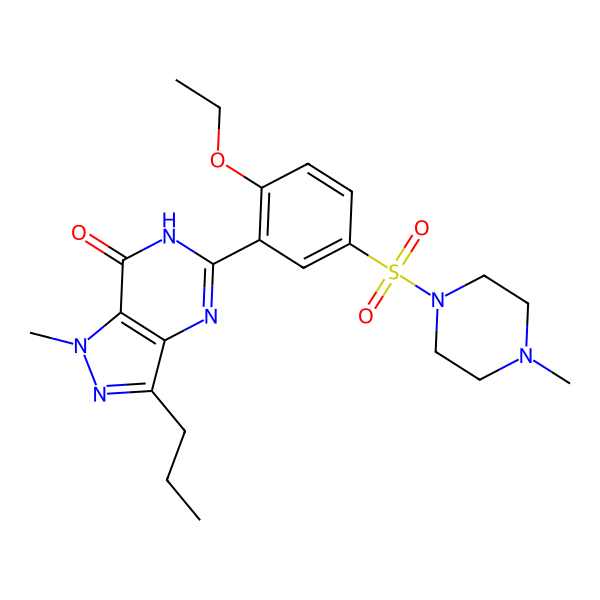

In [14]:
# --- 9-5. (1) 입력 이미지 준비 — RDKit 으로 정답 구조를 PNG 렌더 ---
from pathlib import Path
import matplotlib.pyplot as plt

# colorblind-safe (Okabe-Ito) 팔레트. 이후 모든 차트는 이 상수만 참조한다.
OKABE_ITO = {
    "blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
    "purple": "#CC79A7", "vermillion": "#D55E00", "sky": "#56B4E9",
    "yellow": "#F0E442", "grey": "#999999",
}
plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "font.size": 7,
    "axes.spines.top": False, "axes.spines.right": False,
})

QUERY_IMG_PATH = Path("sildenafil_structure.png")


def render_structure_png(smiles: str, path: Path, size=(600, 600)):
    """SMILES 를 2D 구조 PNG 로 저장한다 (멀티모달 모델의 이미지 입력으로 쓴다)."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"RDKit 파싱 실패: {smiles}")
    img = Draw.MolToImage(mol, size=size)
    img.save(path)
    return img


QUERY_IMG = render_structure_png(TASK_B_SMILES, QUERY_IMG_PATH)
print("입력 이미지 저장:", QUERY_IMG_PATH.resolve())
print("파일 크기: %.0f KB / 해상도: %s" % (QUERY_IMG_PATH.stat().st_size / 1024, QUERY_IMG.size))
print()
print("이 PNG 안에는 SMILES 문자열이 **한 글자도** 들어 있지 않습니다.")
print("모델은 그림만 보고 원자·결합·고리를 읽어 구조 문자열을 복원해야 합니다.")
display(QUERY_IMG)

In [15]:
# --- 9-5. (2) 경로 ③-A : Gemini 비전 왕복 (API 키 없으면 자동 skip) ---
# 이미지 전달 방식은 google-genai 공식 문서에서 확인한 형태를 그대로 쓴다:
#   contents=[프롬프트 문자열, types.Part.from_bytes(data=..., mime_type="image/png")]
VISION_Q_SMILES = ("The image shows the 2D structure of one small molecule. "
                   "Write ONLY its SMILES string. No prose, no code fence, no explanation.")
VISION_Q_DESC = ("The image shows the 2D structure of one small molecule. "
                 "Describe it, including its common drug name, its protein target "
                 "and its clinical indication.")

gemini_vis_raw_smiles = None   # 모델 답변 원문 (a)
gemini_vis_desc = None         # 모델 답변 원문 (b)
gemini_vis_status = "SKIP (API 키 없음)"
gemini_vis_note = "무료 티어 · 키 미설정 — 이미지 입력 미실행"

print("[질의 1 · 이미지 + 텍스트]", VISION_Q_SMILES)
print("[질의 2 · 이미지 + 텍스트]", VISION_Q_DESC)
print()

if GEMINI_CLIENT is None:
    print("=" * 72)
    print("[SKIP] 9-4 에서 Gemini 클라이언트를 만들지 못했습니다 (API 키 없음/호출 실패).")
    print("       세대 ③-A 의 이미지 입력 왕복은 건너뜁니다. 0점으로 기록하지 않습니다.")
    print("=" * 72)
else:
    try:
        from google.genai import types

        image_part = types.Part.from_bytes(
            data=QUERY_IMG_PATH.read_bytes(), mime_type="image/png")

        def ask_gemini_vision(question: str) -> str:
            """이미지 1장 + 질문을 Gemini 에 보내고 텍스트 응답을 돌려준다."""
            resp = GEMINI_CLIENT.models.generate_content(
                model=GEMINI_MODEL, contents=[question, image_part])
            return (resp.text or "").strip()

        gemini_vis_raw_smiles = ask_gemini_vision(VISION_Q_SMILES)
        gemini_vis_desc = ask_gemini_vision(VISION_Q_DESC)
        gemini_vis_status = "실행"
        gemini_vis_note = f"이미지 입력 · {GEMINI_MODEL}"

        print("[Gemini 이미지→SMILES 원문]\n", gemini_vis_raw_smiles[:400])
        print("\n[Gemini 이미지→설명 원문]\n", gemini_vis_desc[:800], "\n")
    except Exception as exc:
        gemini_vis_status = f"SKIP ({type(exc).__name__})"
        gemini_vis_note = f"이미지 입력 호출 실패: {exc}"[:120]
        print("=" * 72)
        print(f"[SKIP] Gemini 이미지 입력 실패: {type(exc).__name__}: {exc}")
        print("=" * 72)

GEMINI_VIS_SMILES = extract_smiles(gemini_vis_raw_smiles)

register("③-A 프론티어 · 이미지 입력", f"gemini · {GEMINI_MODEL or '(미선택)'}",
         smiles_out=GEMINI_VIS_SMILES, desc_out=gemini_vis_desc,
         status=gemini_vis_status, note=gemini_vis_note)

[질의 1 · 이미지 + 텍스트] The image shows the 2D structure of one small molecule. Write ONLY its SMILES string. No prose, no code fence, no explanation.
[질의 2 · 이미지 + 텍스트] The image shows the 2D structure of one small molecule. Describe it, including its common drug name, its protein target and its clinical indication.

[Gemini 이미지→SMILES 원문]
 CCCc1nn(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(C)CC4)ccc3OCC)nc12

[Gemini 이미지→설명 원문]
 Based on the provided chemical structure, here is a detailed description of the molecule:

### 1. **Common Drug Name**
* **Sildenafil** (widely known under trade names such as **Viagra** and **Revatio**).

---

### 2. **Structural Description**
* **Core Scaffold:** 1,6-dihydro-7*H*-pyrazolo[4,3-*d*]pyrimidin-7-one.
* **Substituents:**
  * A **methyl group** at position 1 of the pyrazole ring.
  * A **propyl group** at position 3 of the pyrazole ring.
  * A **2-ethoxy-5-[(4-methylpiperazin-1-yl)sulfonyl]phenyl** group attached at position 5 of the pyrimidinone ring.

---


In [16]:
# --- 9-5. (3) 경로 ③-B 준비 : ChemVLM 이미지 전처리 (모델 카드 파이프라인 그대로) ---
# 아래 4개 함수는 AI4Chem/ChemVLM-8B 모델 카드 Quick Start 의 전처리 코드와 동일하다.
# torchvision 은 GPU 경로에서만 필요하므로 함수 안에서 지연 import 한다.
IMAGENET_MEAN = (0.485, 0.456, 0.406)   # preprocessor_config.json 의 image_mean 과 동일
IMAGENET_STD = (0.229, 0.224, 0.225)    # preprocessor_config.json 의 image_std 와 동일
CHEMVLM_INPUT_SIZE = 448                # config.json: force_image_size = 448
CHEMVLM_MAX_NUM = 6                     # 모델 카드 Quick Start 의 max_num


def build_transform(input_size: int):
    """카드와 동일한 전처리: RGB 변환 → BICUBIC 리사이즈 → ImageNet 정규화."""
    import torchvision.transforms as T
    from torchvision.transforms.functional import InterpolationMode
    return T.Compose([
        T.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


def find_closest_aspect_ratio(aspect_ratio, target_ratios, width, height, image_size):
    """후보 타일 배치 중 원본 종횡비에 가장 가까운 것을 고른다 (카드 원본 로직)."""
    best_ratio_diff, best_ratio = float("inf"), (1, 1)
    area = width * height
    for ratio in target_ratios:
        target_aspect_ratio = ratio[0] / ratio[1]
        ratio_diff = abs(aspect_ratio - target_aspect_ratio)
        if ratio_diff < best_ratio_diff:
            best_ratio_diff, best_ratio = ratio_diff, ratio
        elif ratio_diff == best_ratio_diff:
            if area > 0.5 * image_size * image_size * ratio[0] * ratio[1]:
                best_ratio = ratio
    return best_ratio


def dynamic_preprocess(image, min_num=1, max_num=6, image_size=448, use_thumbnail=False):
    """이미지를 448×448 타일로 분할한다 (카드 원본 로직, config.json use_thumbnail=True)."""
    orig_width, orig_height = image.size
    aspect_ratio = orig_width / orig_height
    target_ratios = sorted(
        {(i, j) for n in range(min_num, max_num + 1)
         for i in range(1, n + 1) for j in range(1, n + 1)
         if min_num <= i * j <= max_num},
        key=lambda x: x[0] * x[1])
    target_aspect_ratio = find_closest_aspect_ratio(
        aspect_ratio, target_ratios, orig_width, orig_height, image_size)
    target_width = image_size * target_aspect_ratio[0]
    target_height = image_size * target_aspect_ratio[1]
    blocks = target_aspect_ratio[0] * target_aspect_ratio[1]

    resized_img = image.resize((target_width, target_height))
    processed_images = []
    for i in range(blocks):
        box = ((i % (target_width // image_size)) * image_size,
               (i // (target_width // image_size)) * image_size,
               ((i % (target_width // image_size)) + 1) * image_size,
               ((i // (target_width // image_size)) + 1) * image_size)
        processed_images.append(resized_img.crop(box))
    if use_thumbnail and len(processed_images) != 1:
        processed_images.append(image.resize((image_size, image_size)))
    return processed_images


def load_image(image_file, input_size: int = 448, max_num: int = 6):
    """PNG 경로 → ChemVLM 이 받는 pixel_values 텐서 (타일 수, 3, 448, 448)."""
    from PIL import Image
    image = Image.open(image_file).convert("RGB")
    transform = build_transform(input_size=input_size)
    images = dynamic_preprocess(image, image_size=input_size,
                                use_thumbnail=True, max_num=max_num)
    return torch.stack([transform(im) for im in images])


print("ChemVLM 전처리 함수 준비 완료 — build_transform / dynamic_preprocess / load_image")
print(f"입력 타일 크기 {CHEMVLM_INPUT_SIZE}x{CHEMVLM_INPUT_SIZE}, max_num={CHEMVLM_MAX_NUM}, use_thumbnail=True")

ChemVLM 전처리 함수 준비 완료 — build_transform / dynamic_preprocess / load_image
입력 타일 크기 448x448, max_num=6, use_thumbnail=True


In [ ]:
# --- 9-5. (4) 경로 ③-B : ChemVLM-8B 실행 (GPU 없으면 자동 skip) ---
CHEMVLM_ID = "AI4Chem/ChemVLM-8B"   # HF 실재 확인: public, image-text-to-text, Apache-2.0

chemvlm_raw_smiles = None
chemvlm_desc = None
chemvlm_status = "SKIP (GPU 필요)"
chemvlm_note = "CPU 환경 — 약 16GB 다운로드/추론 미실행"

if not torch.cuda.is_available():
    print("=" * 72)
    print("[SKIP] GPU를 찾지 못했습니다 (torch.cuda.is_available() == False).")
    print("       8B 멀티모달 모델을 CPU에서 강행하지 않습니다. 경로 ③-B 는 건너뜁니다.")
    print("       Colab: 런타임 > 런타임 유형 변경 > 하드웨어 가속기 > T4(또는 A100) 로 바꾼 뒤 재실행하세요.")
    print("       (수업 기본 경로는 다운로드가 없는 ③-A Gemini 입니다.)")
    print("=" * 72)
else:
    try:
        # 선행 확인: InternVL 원격 코드는 transformers 4.3x 시절에 작성되었다.
        # 4.50 부터 PreTrainedModel 이 GenerationMixin 을 상속하지 않으므로 .generate 가 없고,
        # 이 코드는 post_init() 도 호출하지 않아 all_tied_weights_keys 가 만들어지지 않는다.
        # 실패가 확정된 상태로 16GB 를 내려받지 않도록 다운로드 '전에' 막는다.
        import transformers as _tf
        try:
            _tfv = tuple(int(x) for x in _tf.__version__.split(".")[:2])
        except ValueError:
            _tfv = None                      # 버전 문자열이 예상 밖이면 그냥 진행
        if _tfv is not None and _tfv >= (4, 50):
            raise RuntimeError(
                f"transformers {_tf.__version__} 에서는 InternVL 원격 코드가 동작하지 않습니다 "
                "(GenerationMixin 미상속 / all_tied_weights_keys 부재). "
                "16GB 다운로드 전에 중단했습니다.")

        vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024 ** 3
        use_4bit = vram_gb < 24          # A100 40GB → bf16, T4 16GB → 4bit
        vlm_dtype = torch.float16 if use_4bit else torch.bfloat16

        print(f"GPU: {torch.cuda.get_device_name(0)} / VRAM {vram_gb:.1f} GB")
        print(f"로딩 방식: {'4-bit 양자화 (bitsandbytes)' if use_4bit else 'bfloat16 (양자화 없음)'}"
              f" · 연산 dtype = {vlm_dtype}")
        print(f"[다운로드] {CHEMVLM_ID} — safetensors 4 shard, 약 16 GB. 회선에 따라 5~15분 걸립니다.")
        print("           (진행률 막대가 아래에 표시됩니다. 한 번 받으면 HF 캐시에 남습니다.)")

        deps = {"einops": "einops", "timm": "timm",
                "accelerate": "accelerate", "torchvision": "torchvision"}
        if use_4bit:
            deps["bitsandbytes"] = "bitsandbytes"
        ensure(deps)

        from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

        # 카드 확인 사항: auto_map 이 원격 코드를 가리키므로 trust_remote_code=True 가 필수
        tok_vlm = AutoTokenizer.from_pretrained(CHEMVLM_ID, trust_remote_code=True)

        load_kwargs = dict(torch_dtype=vlm_dtype, low_cpu_mem_usage=True,
                           trust_remote_code=True, device_map="auto")
        if use_4bit:
            load_kwargs["quantization_config"] = BitsAndBytesConfig(
                load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)

        model_vlm = AutoModelForCausalLM.from_pretrained(CHEMVLM_ID, **load_kwargs).eval()
        vlm_device = next(model_vlm.parameters()).device
        print("모델 로드 완료 →", vlm_device)

        pixel_values = load_image(QUERY_IMG_PATH,
                                  input_size=CHEMVLM_INPUT_SIZE,
                                  max_num=CHEMVLM_MAX_NUM).to(vlm_dtype).to(vlm_device)
        print("pixel_values:", tuple(pixel_values.shape), pixel_values.dtype)

        # 카드 예시는 sampling(temperature 0.7)이지만, 채점 재현성을 위해 greedy 로 고정한다.
        gen_kwargs = {"max_new_tokens": 512, "do_sample": False}

        # 카드 확인 사항: generate() 가 아니라 chat(). 프롬프트 템플릿은 chat() 내부가 붙인다.
        chemvlm_raw_smiles = model_vlm.chat(tok_vlm, pixel_values, VISION_Q_SMILES, gen_kwargs)
        chemvlm_desc = model_vlm.chat(tok_vlm, pixel_values, VISION_Q_DESC, gen_kwargs)
        chemvlm_status = "실행"
        chemvlm_note = f"{'4bit' if use_4bit else 'bf16'} · chat() API · {CHEMVLM_INPUT_SIZE}px 타일"

        print("\n[ChemVLM 이미지→SMILES 원문]\n", str(chemvlm_raw_smiles)[:400])
        print("\n[ChemVLM 이미지→설명 원문]\n", str(chemvlm_desc)[:800], "\n")
    except Exception as exc:
        chemvlm_status = f"SKIP ({type(exc).__name__})"
        chemvlm_note = f"로딩/추론 실패: {exc}"[:120]
        print("=" * 72)
        print(f"[SKIP] ChemVLM 실행 실패: {type(exc).__name__}: {exc}")
        msg = str(exc)
        if "null character" in msg:
            print("       원인: sentencepiece 0.2.x 가 InternLM2 tokenizer.model 을 거부.")
            print("       해결: !pip install -q 'sentencepiece==0.1.99' 후 [세션 다시 시작].")
        elif ("all_tied_weights_keys" in msg) or ("GenerationMixin" in msg) or ("generate" in msg):
            print("       원인: InternVL 원격 코드가 transformers 4.3x 시절 작성 —")
            print("             4.50+ 에서는 PreTrainedModel 이 GenerationMixin 을 상속하지 않아 .generate 가 없고,")
            print("             post_init() 미호출로 all_tied_weights_keys 도 만들어지지 않습니다.")
            print("       해결: ChemVLM 전용 런타임에서 아래 실행 후 [세션 다시 시작].")
            print("             !pip install -q 'transformers==4.44.2' 'sentencepiece==0.1.99'")
            print("       ※ 수업 진행에는 지장 없습니다 — 멀티모달 요지는 ③-A Gemini(이미지) 경로가 담당합니다.")
        else:
            print("       위 메시지를 확인하세요.")
        print("=" * 72)

CHEMVLM_SMILES = extract_smiles(chemvlm_raw_smiles)

register("③-B 오픈 멀티모달 · 이미지 입력", CHEMVLM_ID,
         smiles_out=CHEMVLM_SMILES, desc_out=chemvlm_desc,
         status=chemvlm_status, note=chemvlm_note)

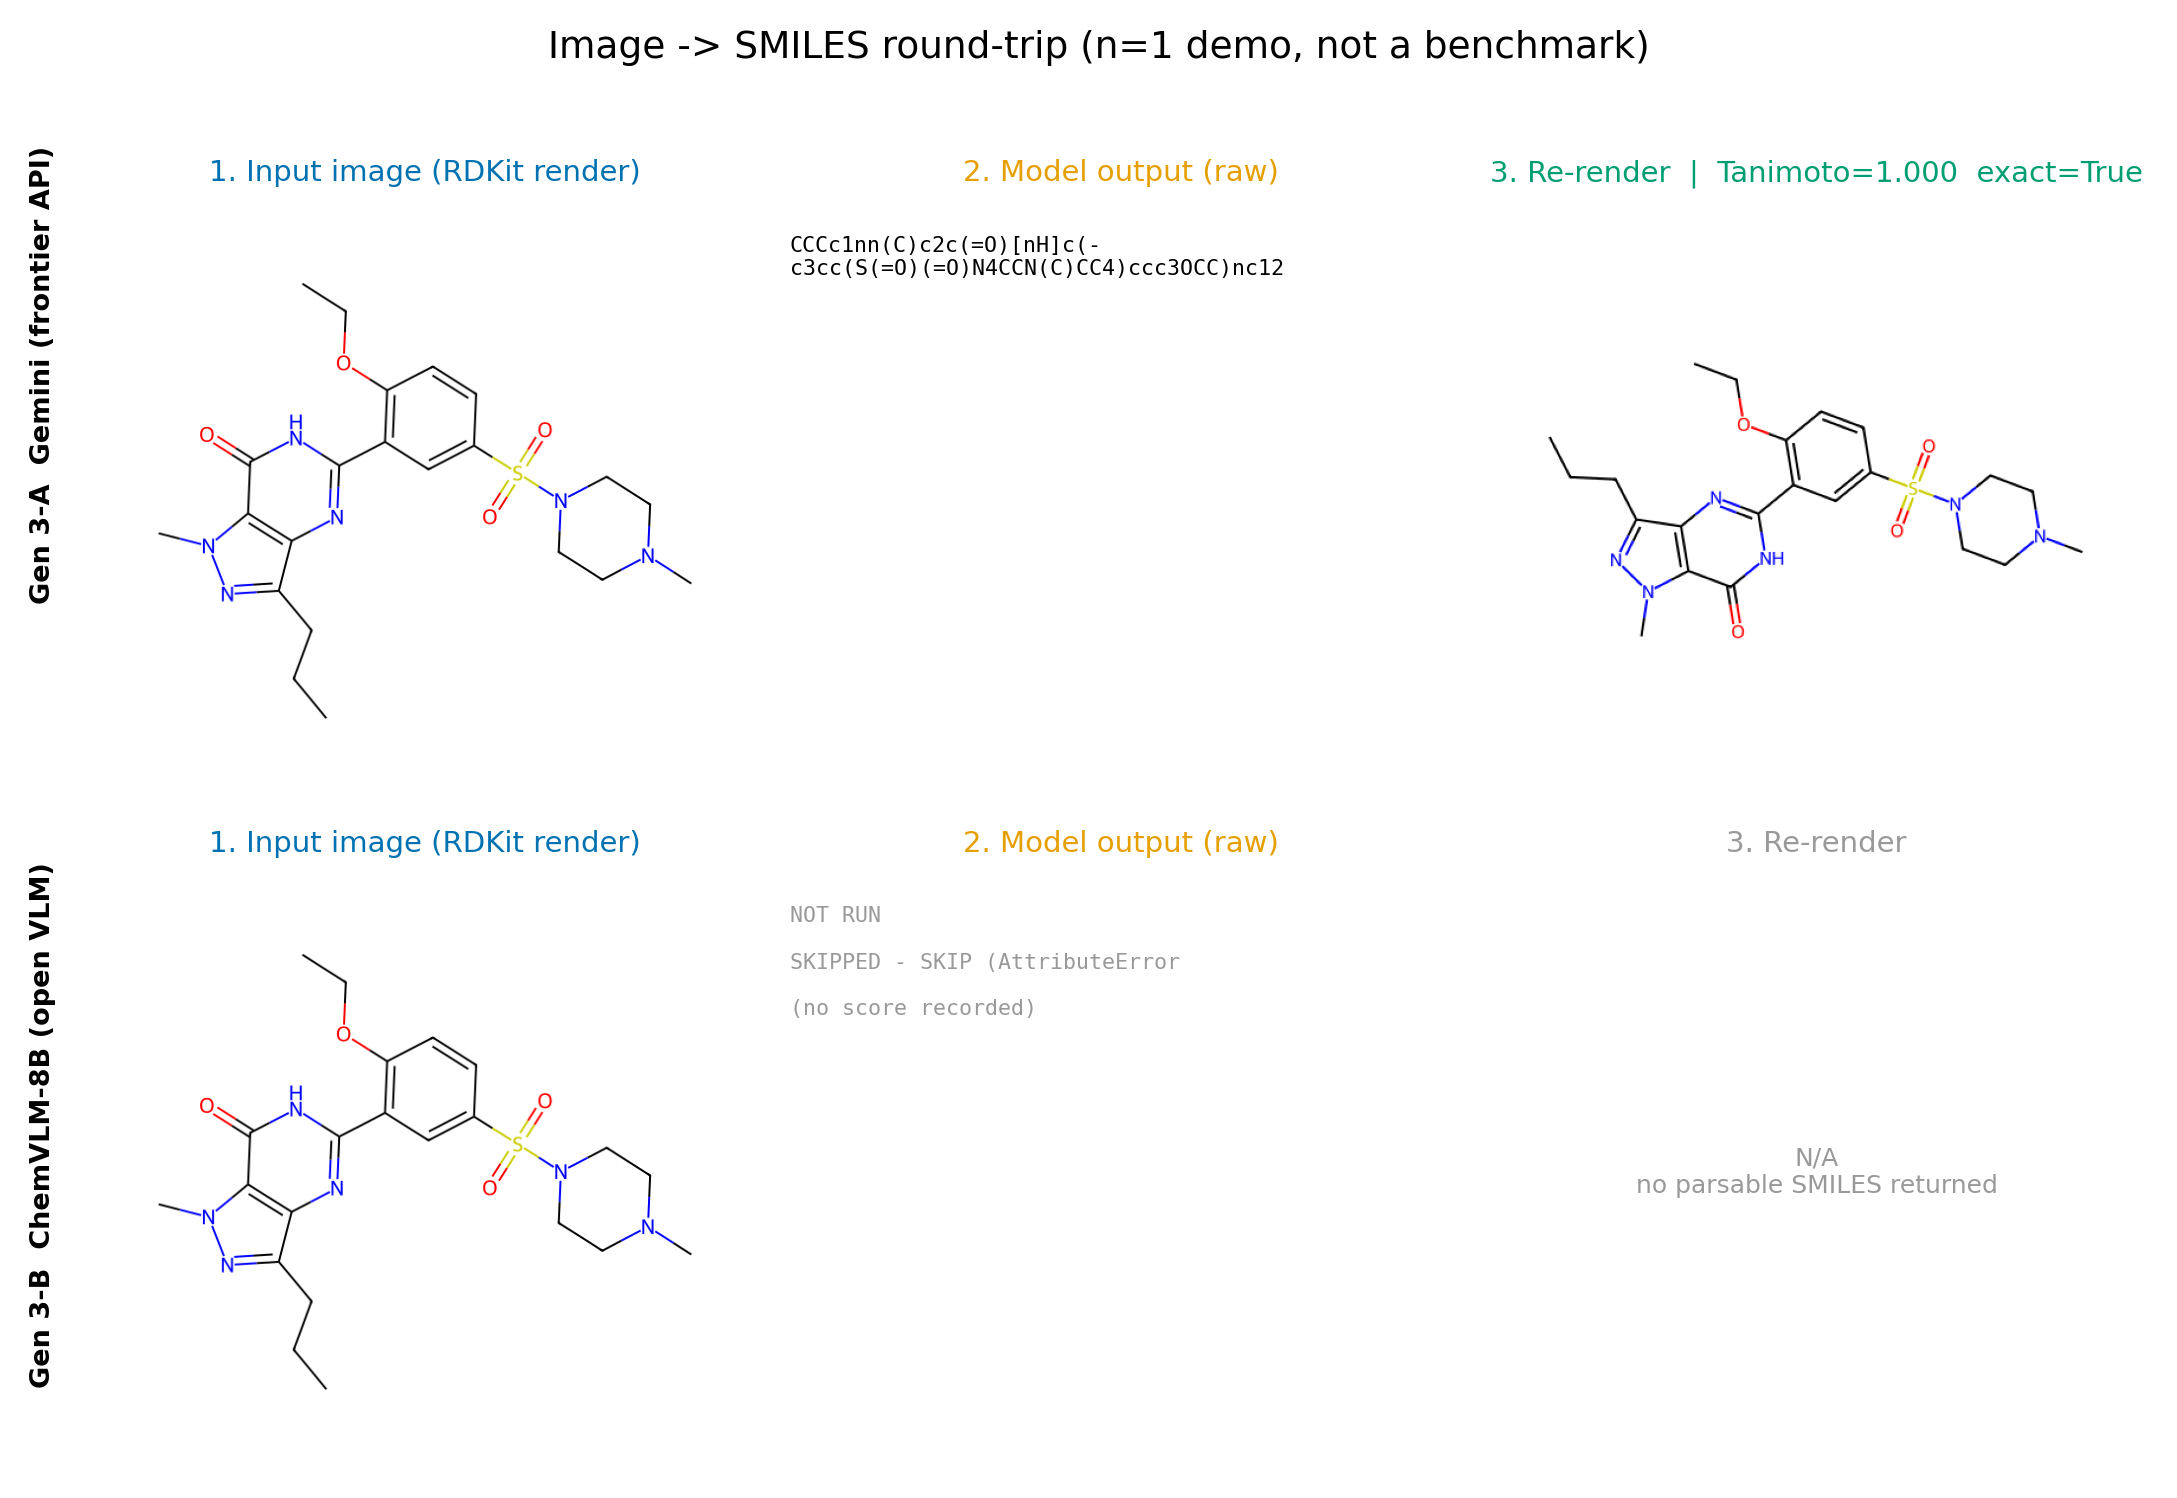

판정 기준: 패널 3 이 그려졌으면 '문자열이 파싱은 되었다'는 뜻일 뿐입니다.
           구조가 정답과 같은지는 Tanimoto 와 exact 값으로만 판단합니다.


In [18]:
# --- 9-5. (5) 왕복 검증 3단 패널 : 입력 이미지 → 반환 SMILES → 재렌더 ---
import textwrap


def status_en(status: str) -> str:
    """차트 안에는 영문만 넣는다 — 한국어 상태 문자열을 영문 라벨로 바꾼다."""
    if status.startswith("실행"):
        return "RAN"
    if "API" in status:
        return "SKIPPED - no API key"
    if "GPU" in status:
        return "SKIPPED - no GPU"
    ascii_only = re.sub(r"[^\x00-\x7F]+", " ", status).strip(" ()")
    return f"SKIPPED - {ascii_only}" if ascii_only else "SKIPPED"


# 멀티모달 두 경로를 같은 판형으로 나란히 본다 (미실행 경로도 회색 N/A 패널로 남긴다).
ROUNDTRIP_PATHS = [
    ("Gen 3-A  Gemini (frontier API)", gemini_vis_raw_smiles, GEMINI_VIS_SMILES, gemini_vis_status),
    ("Gen 3-B  ChemVLM-8B (open VLM)", chemvlm_raw_smiles, CHEMVLM_SMILES, chemvlm_status),
]

fig, axes = plt.subplots(len(ROUNDTRIP_PATHS), 3,
                         figsize=(7.2, 2.5 * len(ROUNDTRIP_PATHS)))
axes = axes.reshape(len(ROUNDTRIP_PATHS), 3)

for row, (label, raw_text, parsed_smiles, status) in enumerate(ROUNDTRIP_PATHS):
    ax_in, ax_txt, ax_out = axes[row]

    # 패널 1 — 입력 이미지 (항상 동일)
    ax_in.imshow(QUERY_IMG)
    ax_in.set_title("1. Input image (RDKit render)", fontsize=7, color=OKABE_ITO["blue"])
    ax_in.axis("off")

    # 패널 2 — 모델이 돌려준 원문 텍스트
    ax_txt.axis("off")
    ax_txt.set_title("2. Model output (raw)", fontsize=7, color=OKABE_ITO["orange"])
    if raw_text:
        body = "\n".join(textwrap.wrap(str(raw_text).strip()[:300], width=42))
    else:
        body = f"NOT RUN\n\n{status_en(status)}\n\n(no score recorded)"
    ax_txt.text(0.0, 0.95, body, va="top", ha="left", fontsize=5.2,
                family="monospace",
                color="black" if raw_text else OKABE_ITO["grey"], transform=ax_txt.transAxes)

    # 패널 3 — 반환된 SMILES 를 RDKit 으로 다시 그린 구조
    ax_out.axis("off")
    gen_mol = Chem.MolFromSmiles(parsed_smiles) if parsed_smiles else None
    if gen_mol is not None:
        tani = DataStructs.TanimotoSimilarity(_MORGAN.GetFingerprint(gen_mol), _REF_FP)
        exact = Chem.MolToSmiles(gen_mol) == REF_CANONICAL
        ax_out.imshow(Draw.MolToImage(gen_mol, size=(500, 500)))
        ax_out.set_title(f"3. Re-render  |  Tanimoto={tani:.3f}  exact={exact}",
                         fontsize=7, color=OKABE_ITO["green"])
    else:
        ax_out.text(0.5, 0.5, "N/A\nno parsable SMILES returned",
                    ha="center", va="center", fontsize=6, color=OKABE_ITO["grey"])
        ax_out.set_title("3. Re-render", fontsize=7, color=OKABE_ITO["grey"])

    fig.text(0.005, 1 - (row + 0.5) / len(ROUNDTRIP_PATHS), label,
             rotation=90, va="center", ha="left", fontsize=6.5, weight="bold")

fig.suptitle("Image -> SMILES round-trip (n=1 demo, not a benchmark)", fontsize=9)
fig.tight_layout(rect=(0.02, 0, 1, 0.96))
plt.show()

print("판정 기준: 패널 3 이 그려졌으면 '문자열이 파싱은 되었다'는 뜻일 뿐입니다.")
print("           구조가 정답과 같은지는 Tanimoto 와 exact 값으로만 판단합니다.")


### 9-6. 결과 비교 — 표와 그림

**표와 차트에 들어가는 숫자는 전부 이 노트북이 방금 계산한 값입니다.** 논문 벤치마크 점수를 가져다 섞지 않았습니다.
건너뛴 경로는 `SKIP` / `-` 로 남고, 0점이나 빈칸으로 위장하지 않습니다.


In [19]:
# --- 9-6. 비교 표 ---
summary = pd.DataFrame(RESULTS)[
    ["세대", "모델", "상태", "SMILES 유효", "정답 일치", "Tanimoto", "설명 키워드", "적중 키워드", "비고"]
]
display(summary)

print("\n[상세 출력]")
for r in RESULTS:
    print("-" * 72)
    print(f"{r['세대']} | {r['모델']} | {r['상태']}")
    print("  (a) SMILES :", r["생성 SMILES"])
    print("      canonical:", r["canonical"])
    desc = r["설명 출력"]
    print("  (b) 설명   :", (desc[:300] + " ...") if desc and len(desc) > 300 else desc)

print("\n정답(실데나필) canonical:", REF_CANONICAL)

,세대,모델,상태,SMILES 유효,정답 일치,Tanimoto,설명 키워드,적중 키워드,비고
0,① 전용 번역기 (2022),"laituan245/molt5-large-{caption2smiles, smiles...",실행,True,False,0.063,0/5,,태스크별 체크포인트 2개 필요 · 대화 불가
1,② 화학 지시학습 LLM (2024),OpenDFM/ChemDFM-v1.5-8B,실행,True,False,0.879,0/5,,4bit 양자화 · [Round N] 템플릿
2,③-A 프론티어 · 텍스트 입력,gemini · gemini-3.7-flash,실행,True,True,1.0,5/5,"pde5,phosphodiesterase,erectile,sildenafil,pul...",상용 API 무료 티어 · 텍스트 입력
3,③-A 프론티어 · 이미지 입력,gemini · gemini-3.7-flash,실행,True,True,1.0,5/5,"pde5,phosphodiesterase,erectile,sildenafil,pul...",이미지 입력 · gemini-3.7-flash
4,③-B 오픈 멀티모달 · 이미지 입력,AI4Chem/ChemVLM-8B,SKIP (AttributeError),-,-,-,-,-,로딩/추론 실패: 'InternVLChatModel' object has no at...



[상세 출력]
------------------------------------------------------------------------
① 전용 번역기 (2022) | laituan245/molt5-large-{caption2smiles, smiles2caption} | 실행
  (a) SMILES : CC(C)(C)C1=CC=C(C=C1)CC(C)(C)NCC(C2=CC(=C(C=C2)F)F)O
      canonical: CC(C)(Cc1ccc(C(C)(C)C)cc1)NCC(O)c1ccc(F)c(F)c1
  (b) 설명   : The molecule is a member of the class of pyrazoles that is 1H-pyrazole which is substituted at positions 1, 3, and 5 by ethyl, sulfamoyl, and cyclohexyl groups, respectively. A selective cyclooxygenase 2 inhibitor, it is used in veterinary medicine to treat pain and inflammation in dogs with degener ...
------------------------------------------------------------------------
② 화학 지시학습 LLM (2024) | OpenDFM/ChemDFM-v1.5-8B | 실행
  (a) SMILES : CCCc1nn(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(CC)CC4)ccc3OCC)nc12
      canonical: CCCc1nn(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(CC)CC4)ccc3OCC)nc12
  (b) 설명   : The molecule is a benzenesulfonamide.
-----------------------------------------------------

그림에 넣을 분자 5개 (정답 1 + 유효 생성 4)


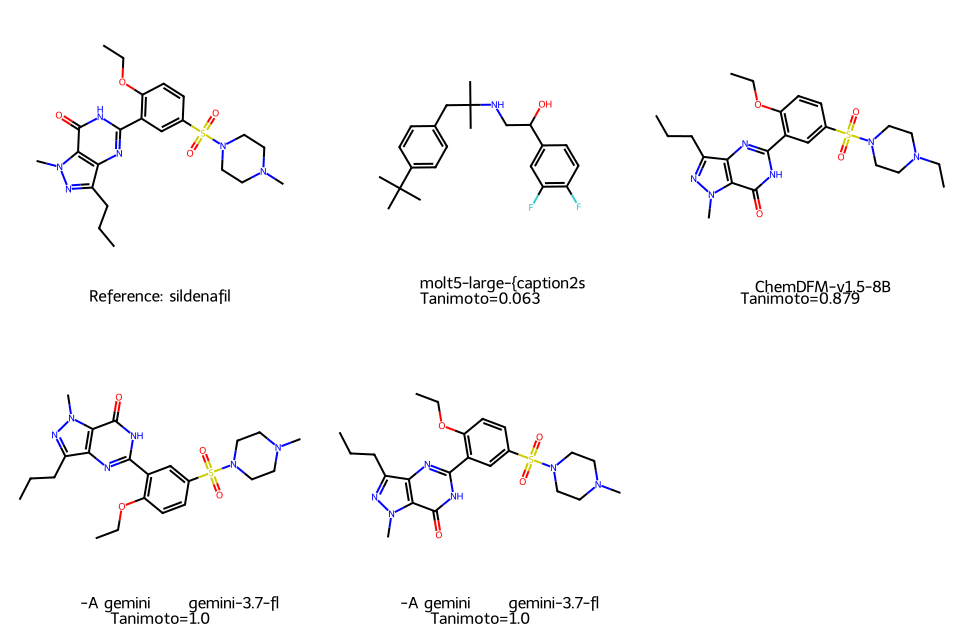

In [20]:
# --- 9-6. 생성 분자 vs 정답 나란히 보기 (전체 그리드) ---
mols, legends = [REF_MOL], ["Reference: sildenafil"]
for r in RESULTS:
    if r["SMILES 유효"] is True:
        mols.append(Chem.MolFromSmiles(r["생성 SMILES"]))
        legends.append(f"{r['세대'].split()[0]} {r['모델'].split('/')[-1][:22]}\nTanimoto={r['Tanimoto']}")

print(f"그림에 넣을 분자 {len(mols)}개 (정답 1 + 유효 생성 {len(mols) - 1})")
if len(mols) == 1:
    print("[안내] 유효한 SMILES를 생성한 세대가 없어 정답 구조만 표시합니다.")

display(Draw.MolsToGridImage(mols, legends=legends,
                             molsPerRow=min(3, len(mols)), subImgSize=(320, 320)))

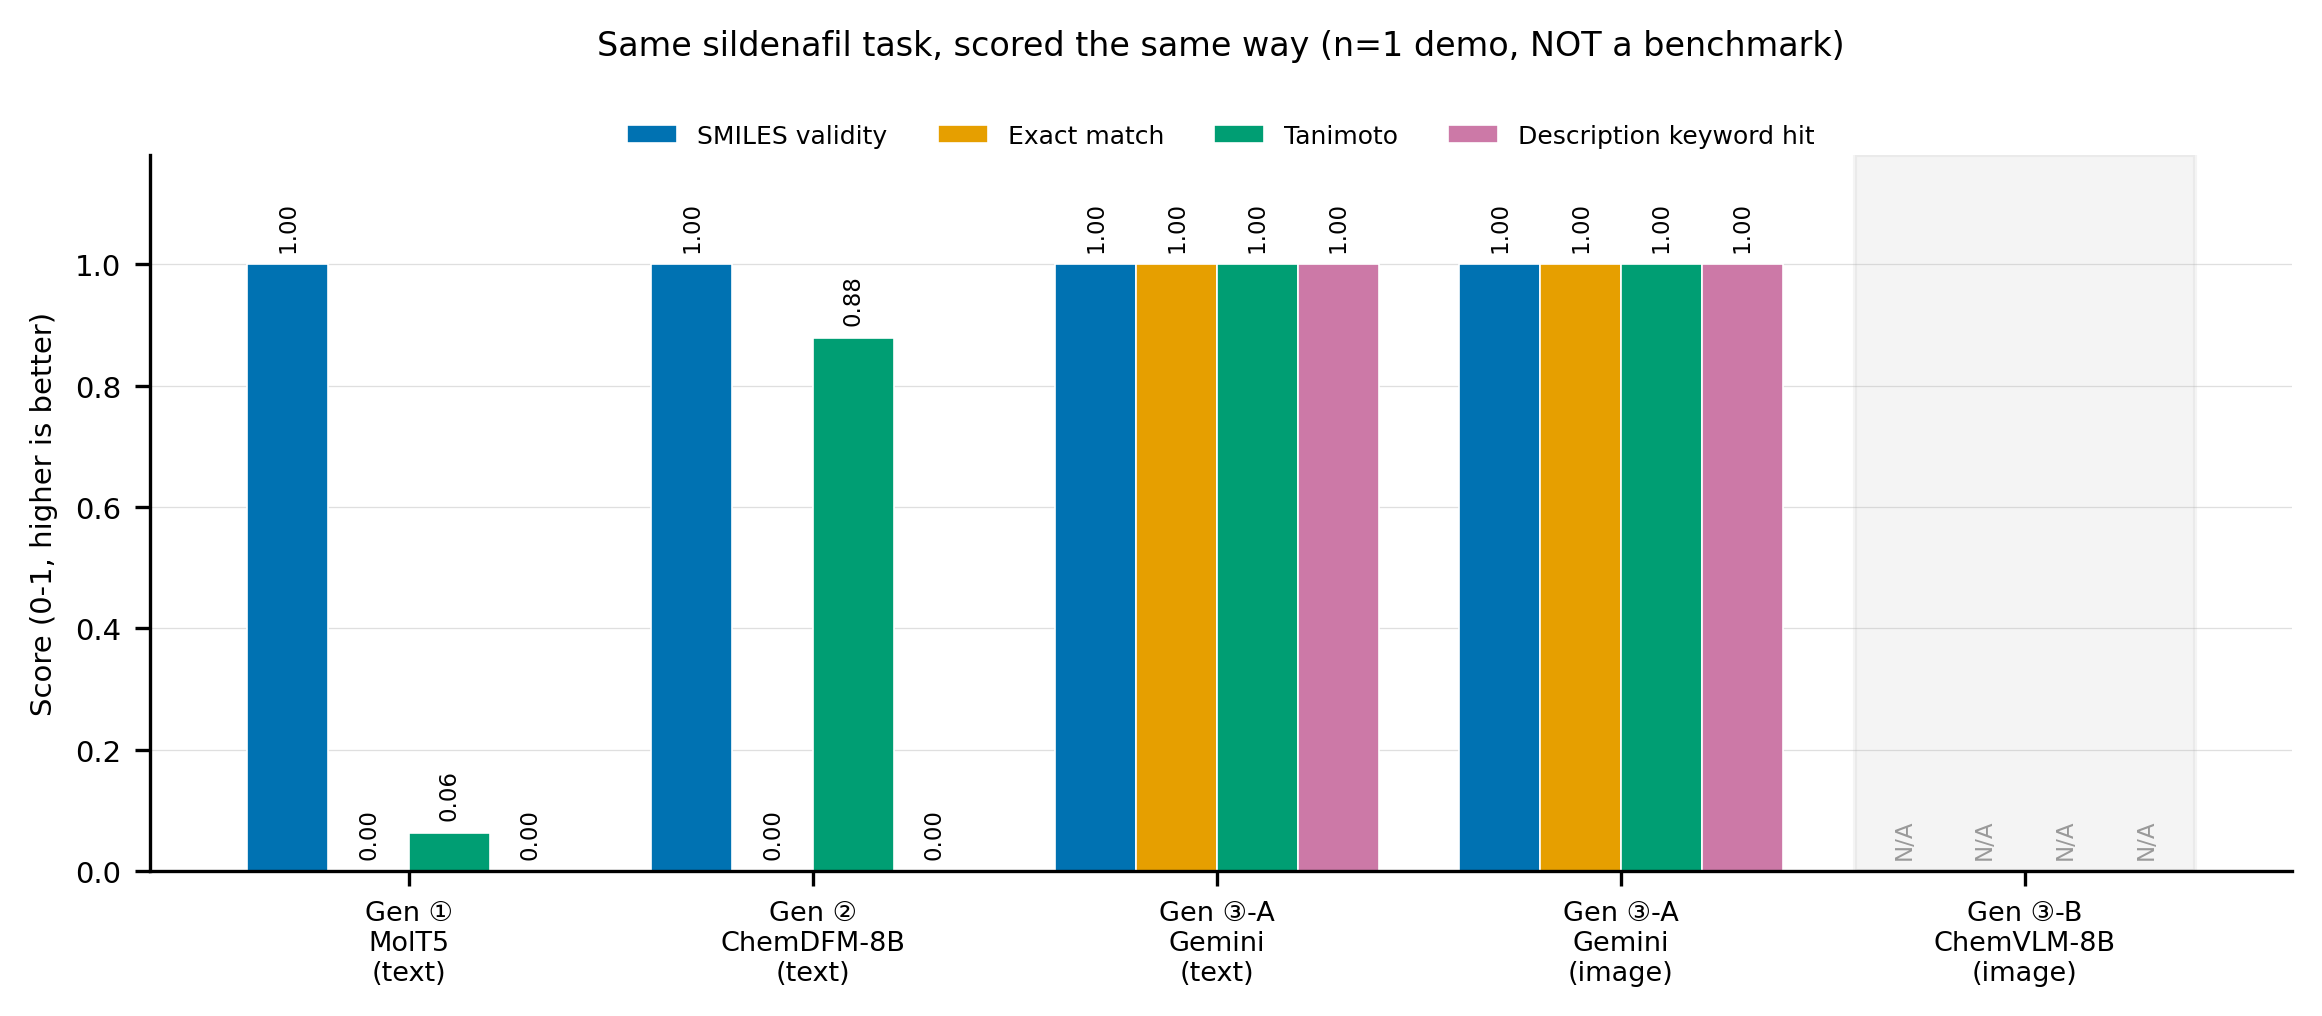

회색 구간 = 실행하지 않은 경로 (GPU/API 키 없음). 0점이 아니라 '측정값 없음' 입니다.
Tanimoto 는 Morgan fingerprint (radius=2, 2048 bit) 기준,
Description keyword hit 는 ['pde5', 'phosphodiesterase', 'erectile', 'sildenafil', 'pulmonary'] 중 적중 비율입니다.


In [21]:
# --- 9-6. 3세대 채점 비교 차트 (미실행 경로는 회색 N/A, 0점으로 칠하지 않음) ---
import numpy as np

METRICS = ["SMILES validity", "Exact match", "Tanimoto", "Description keyword hit"]
METRIC_COLORS = [OKABE_ITO["blue"], OKABE_ITO["orange"],
                 OKABE_ITO["green"], OKABE_ITO["purple"]]

GEN_LABEL_EN = {
    "① 전용 번역기 (2022)":            "Gen ①\nMolT5\n(text)",
    "② 화학 지시학습 LLM (2024)":      "Gen ②\nChemDFM-8B\n(text)",
    "③-A 프론티어 · 텍스트 입력":       "Gen ③-A\nGemini\n(text)",
    "③-A 프론티어 · 이미지 입력":       "Gen ③-A\nGemini\n(image)",
    "③-B 오픈 멀티모달 · 이미지 입력":  "Gen ③-B\nChemVLM-8B\n(image)",
}


def metric_values(row: dict) -> list:
    """한 행을 0-1 스케일 4지표로 바꾼다. 미실행이면 None (막대를 그리지 않는다)."""
    if row["SMILES 유효"] == "-":           # register() 가 '-' 로 남긴 미실행 행
        return [None] * 4
    valid = 1.0 if row["SMILES 유효"] is True else 0.0
    exact = 1.0 if row["정답 일치"] is True else 0.0
    tani = float(row["Tanimoto"]) if isinstance(row["Tanimoto"], (int, float)) else 0.0
    hits = int(str(row["설명 키워드"]).split("/")[0]) if "/" in str(row["설명 키워드"]) else 0
    return [valid, exact, tani, hits / len(DESC_KEYWORDS)]


labels = [GEN_LABEL_EN.get(r["세대"], r["세대"]) for r in RESULTS]
values = [metric_values(r) for r in RESULTS]

x = np.arange(len(RESULTS))
width = 0.2
fig, ax = plt.subplots(figsize=(1.35 * len(RESULTS) + 1.0, 3.4))

labelled = set()
for m, (name, color) in enumerate(zip(METRICS, METRIC_COLORS)):
    offset = (m - 1.5) * width
    for i, v in enumerate(values):
        if v[m] is None:                    # 미실행 — 회색 N/A 만 표시 (막대 없음)
            ax.text(x[i] + offset, 0.02, "N/A", rotation=90, ha="center", va="bottom",
                    fontsize=5.5, color=OKABE_ITO["grey"])
        else:
            ax.bar(x[i] + offset, v[m], width, color=color,
                   edgecolor="white", linewidth=0.4,
                   label=None if name in labelled else name)
            labelled.add(name)
            ax.text(x[i] + offset, v[m] + 0.02, f"{v[m]:.2f}", rotation=90,
                    ha="center", va="bottom", fontsize=5.5)

# 미실행 세대 구간을 옅은 회색으로 덮어 "0점이 아니라 데이터 없음"임을 시각적으로 못박는다
for i, v in enumerate(values):
    if v[0] is None:
        ax.axvspan(x[i] - 0.42, x[i] + 0.42, color=OKABE_ITO["grey"], alpha=0.10, zorder=0)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=6.5)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score (0-1, higher is better)")
ax.set_title("Same sildenafil task, scored the same way (n=1 demo, NOT a benchmark)",
             fontsize=8, pad=24)
# 범례는 축 위로 빼서 막대 위 값 라벨과 겹치지 않게 한다
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.075), ncol=4, fontsize=6, frameon=False)
ax.grid(axis="y", linewidth=0.3, alpha=0.4)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

print("회색 구간 = 실행하지 않은 경로 (GPU/API 키 없음). 0점이 아니라 '측정값 없음' 입니다.")
print("Tanimoto 는 Morgan fingerprint (radius=2, 2048 bit) 기준,")
print(f"Description keyword hit 는 {DESC_KEYWORDS} 중 적중 비율입니다.")

유효한 SMILES 를 낸 경로 4개 / 전체 5개
[Gen 1 MolT5 (text)] MCS 7 atoms / 6 bonds, Tanimoto=0.063, exact=False
[Gen 2 ChemDFM-8B (text)] MCS 33 atoms / 36 bonds, Tanimoto=0.879, exact=False
[Gen 3-A Gemini (text)] MCS 33 atoms / 36 bonds, Tanimoto=1.0, exact=True
[Gen 3-A Gemini (image)] MCS 33 atoms / 36 bonds, Tanimoto=1.0, exact=True


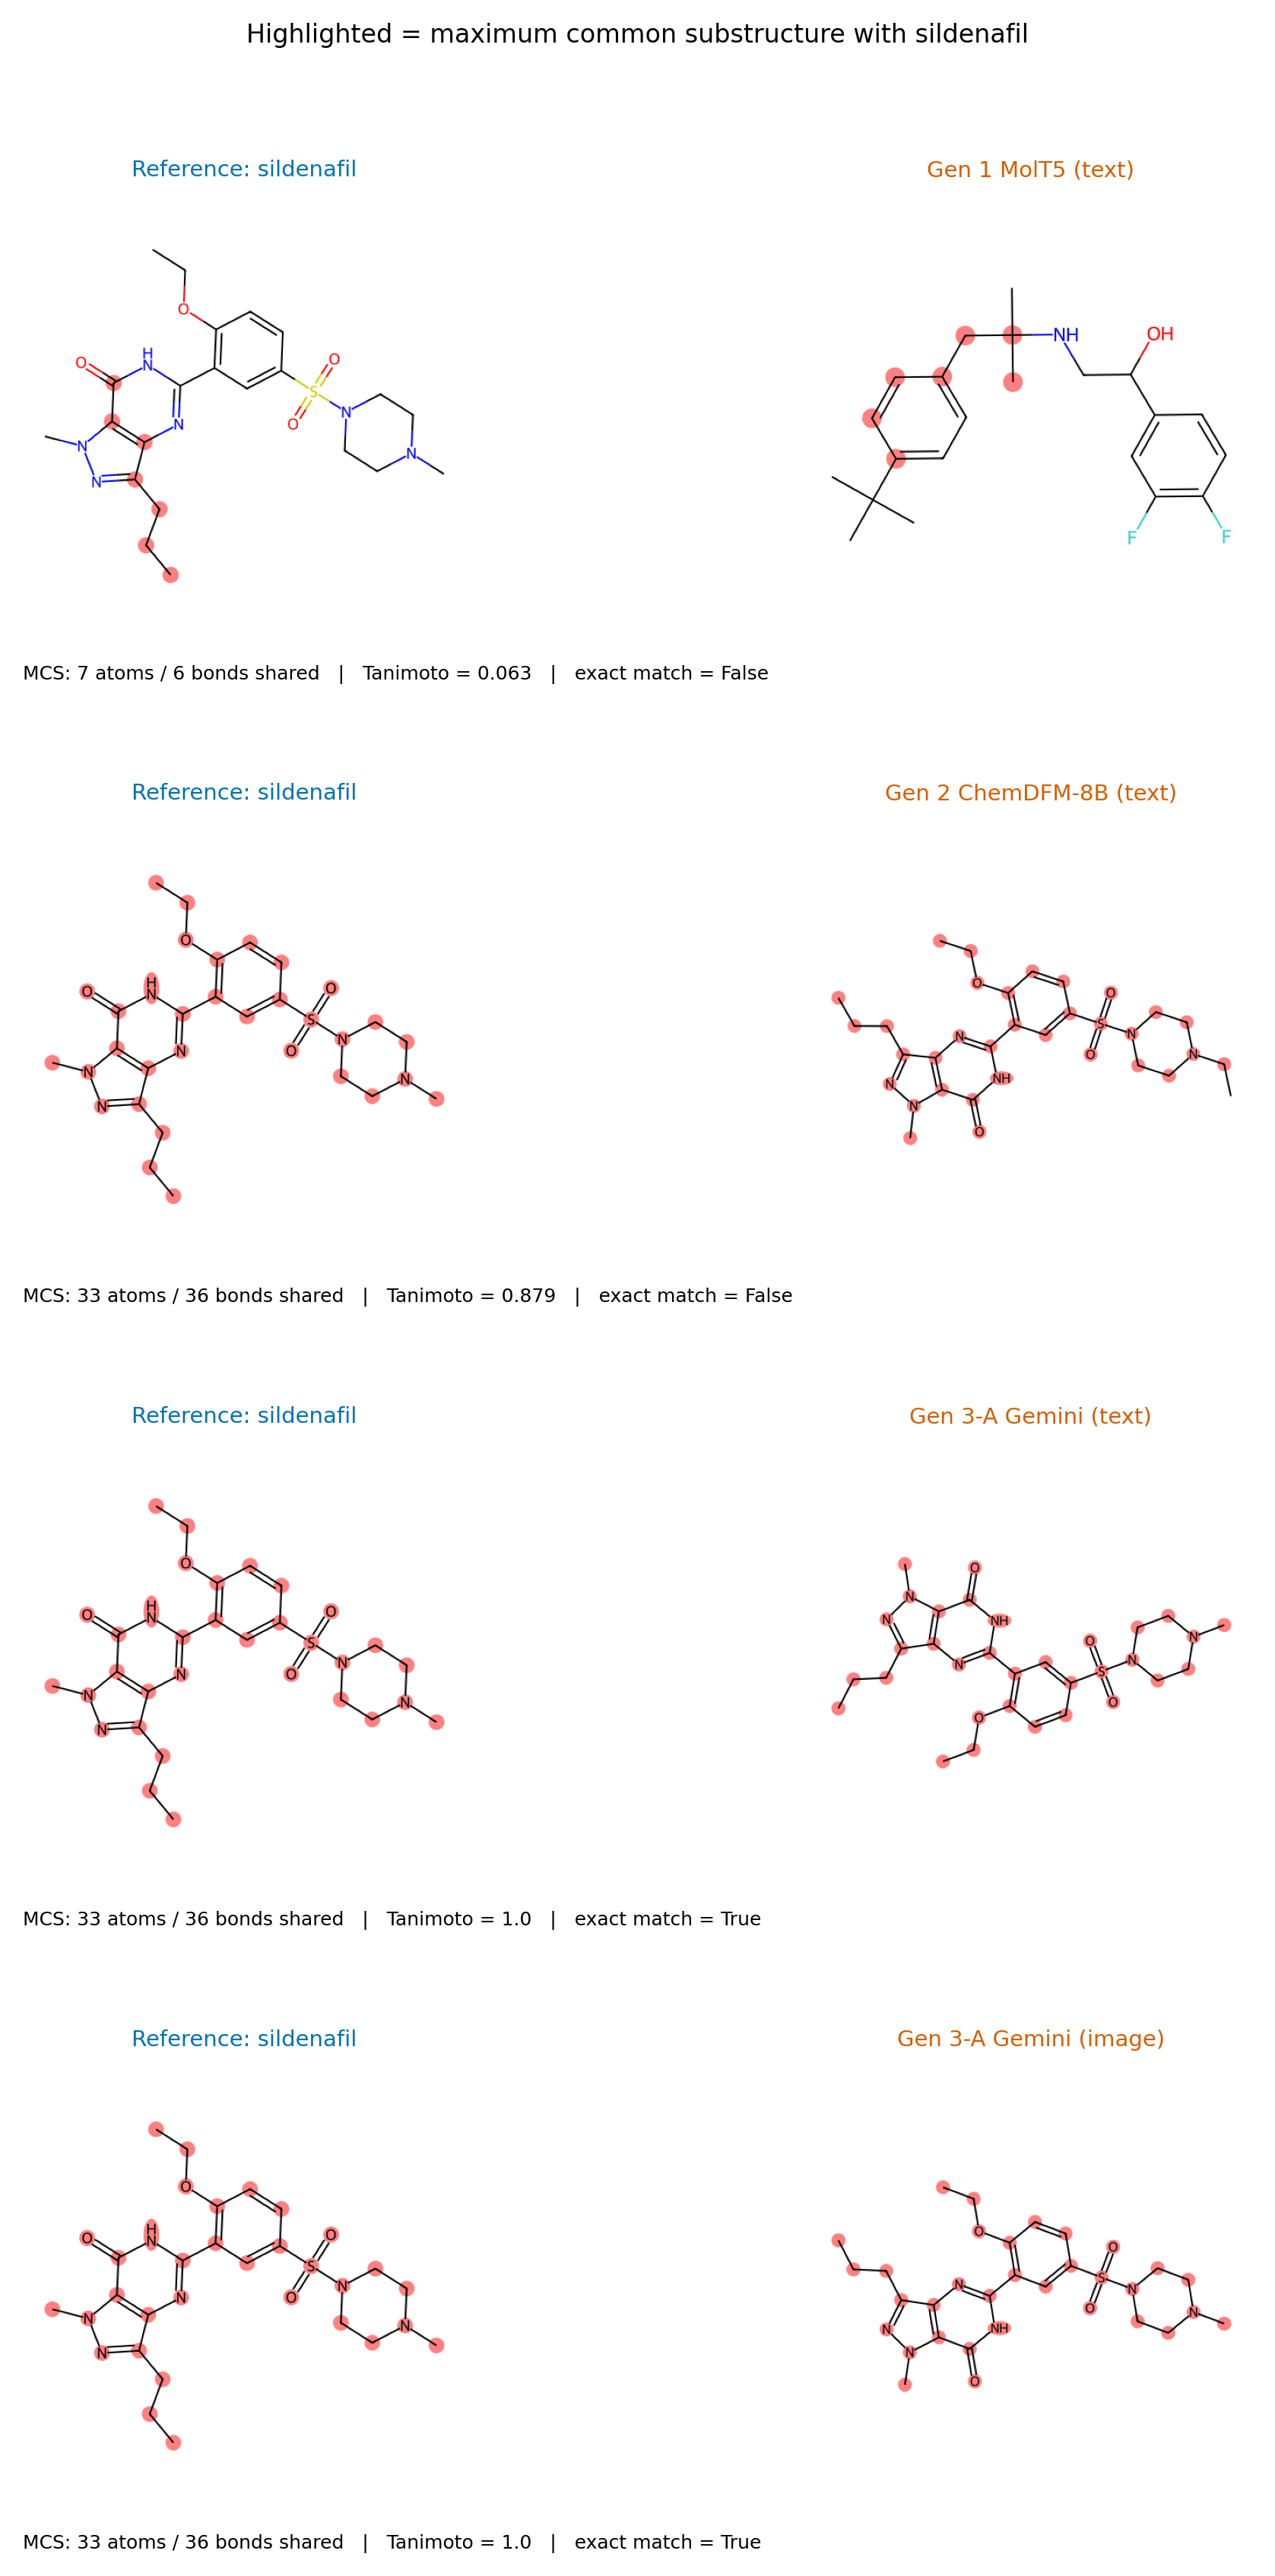


하이라이트된 원자가 정답과 겹치는 부분입니다. 하이라이트 밖이 곧 '어디서 틀렸는가' 입니다.


In [22]:
# --- 9-6. 생성 분자 vs 정답 : 최대공통부분구조(MCS) 하이라이트 ---
from rdkit.Chem import rdFMCS

GEN_SHORT_EN = {
    "① 전용 번역기 (2022)":            "Gen 1 MolT5 (text)",
    "② 화학 지시학습 LLM (2024)":      "Gen 2 ChemDFM-8B (text)",
    "③-A 프론티어 · 텍스트 입력":       "Gen 3-A Gemini (text)",
    "③-A 프론티어 · 이미지 입력":       "Gen 3-A Gemini (image)",
    "③-B 오픈 멀티모달 · 이미지 입력":  "Gen 3-B ChemVLM-8B (image)",
}

valid_rows = [r for r in RESULTS if r["SMILES 유효"] is True]
print(f"유효한 SMILES 를 낸 경로 {len(valid_rows)}개 / 전체 {len(RESULTS)}개")

if not valid_rows:
    fig, ax = plt.subplots(figsize=(3.2, 3.4))
    ax.imshow(Draw.MolToImage(REF_MOL, size=(500, 500)))
    ax.set_title("Reference: sildenafil\n(no valid generated SMILES to compare)", fontsize=7)
    ax.axis("off")
    fig.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(len(valid_rows), 2, figsize=(5.6, 2.9 * len(valid_rows)))
    axes = np.array(axes).reshape(len(valid_rows), 2)

    for row, r in enumerate(valid_rows):
        gen_mol = Chem.MolFromSmiles(r["생성 SMILES"])
        mcs = rdFMCS.FindMCS([REF_MOL, gen_mol], timeout=15,
                             ringMatchesRingOnly=True, completeRingsOnly=False)
        patt = Chem.MolFromSmarts(mcs.smartsString) if mcs.smartsString else None
        ref_hit = list(REF_MOL.GetSubstructMatch(patt)) if patt else []
        gen_hit = list(gen_mol.GetSubstructMatch(patt)) if patt else []

        axes[row, 0].imshow(Draw.MolToImage(REF_MOL, size=(520, 520), highlightAtoms=ref_hit))
        axes[row, 0].set_title("Reference: sildenafil", fontsize=7, color=OKABE_ITO["blue"])
        axes[row, 0].axis("off")

        axes[row, 1].imshow(Draw.MolToImage(gen_mol, size=(520, 520), highlightAtoms=gen_hit))
        axes[row, 1].set_title(GEN_SHORT_EN.get(r["세대"], r["세대"]),
                               fontsize=7, color=OKABE_ITO["vermillion"])
        axes[row, 1].axis("off")

        cap = (f"MCS: {mcs.numAtoms} atoms / {mcs.numBonds} bonds shared"
               f"   |   Tanimoto = {r['Tanimoto']}"
               f"   |   exact match = {r['정답 일치']}")
        axes[row, 0].text(0.0, -0.06, cap, transform=axes[row, 0].transAxes,
                          fontsize=6, va="top", ha="left")
        print(f"[{GEN_SHORT_EN.get(r['세대'], r['세대'])}] MCS {mcs.numAtoms} atoms / "
              f"{mcs.numBonds} bonds, Tanimoto={r['Tanimoto']}, exact={r['정답 일치']}")

    fig.suptitle("Highlighted = maximum common substructure with sildenafil", fontsize=8)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()

print()
print("하이라이트된 원자가 정답과 겹치는 부분입니다. 하이라이트 밖이 곧 '어디서 틀렸는가' 입니다.")

Gen 1 MolT5 (text)               MW=  361.5  logP=  4.91  (ref MW=474.6, logP=1.61)
Gen 2 ChemDFM-8B (text)          MW=  488.6  logP=  2.00  (ref MW=474.6, logP=1.61)
Gen 3-A Gemini (text)            MW=  474.6  logP=  1.61  (ref MW=474.6, logP=1.61)
Gen 3-A Gemini (image)           MW=  474.6  logP=  1.61  (ref MW=474.6, logP=1.61)


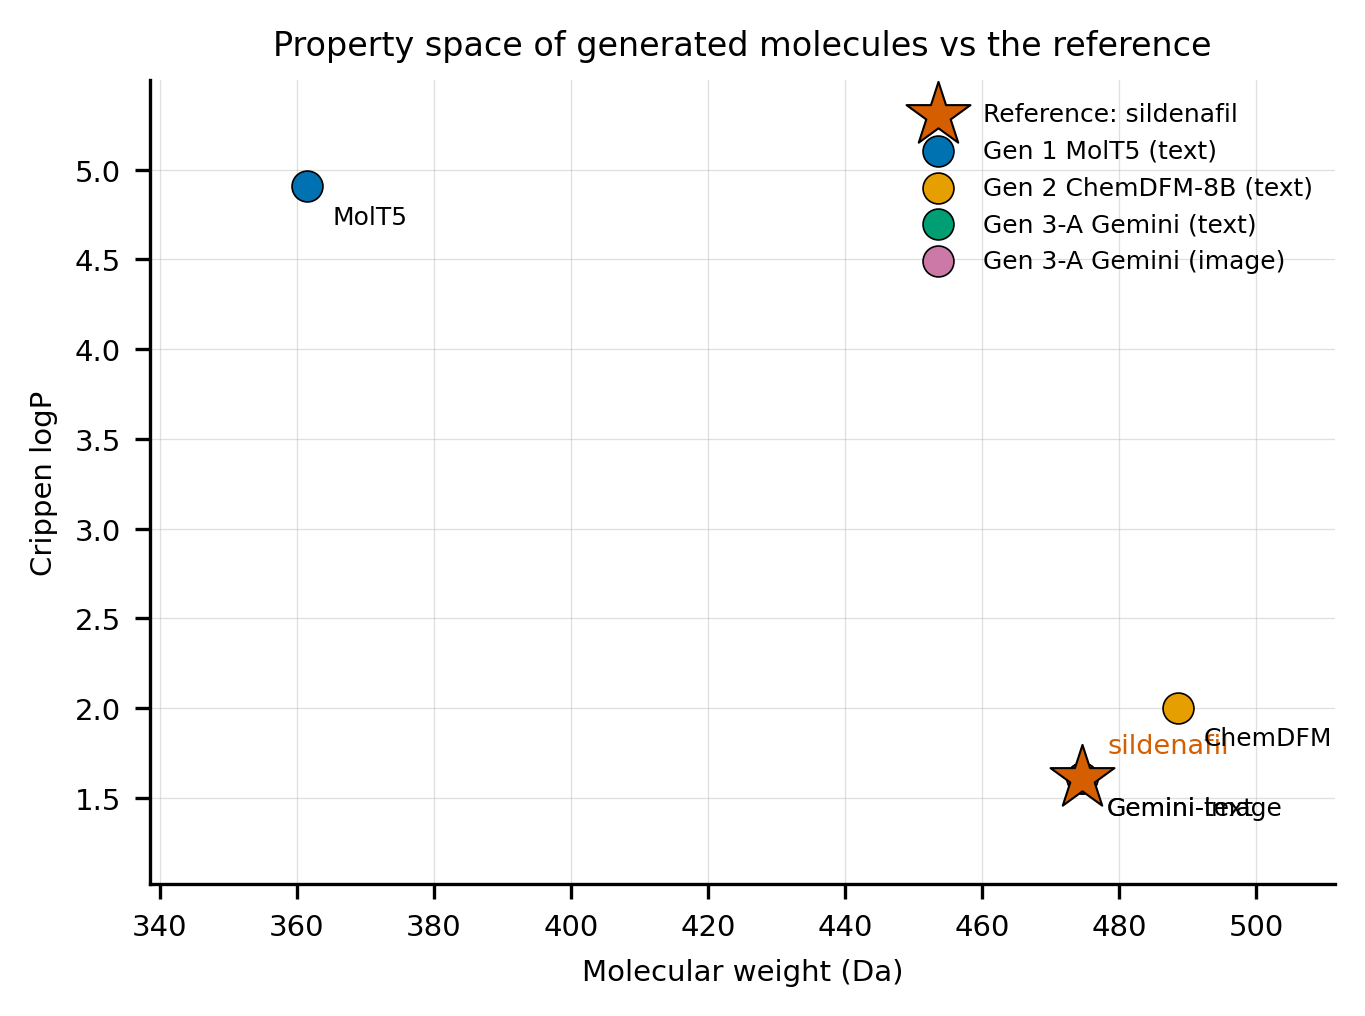

MW 와 logP 는 RDKit Descriptors / Crippen 으로 이 노트북이 직접 계산한 값입니다.
가까이 있다고 같은 분자가 아닙니다 — 물성이 비슷해도 골격은 전혀 다를 수 있습니다.


In [23]:
# --- 9-6. 물성 공간 비교 : MW vs logP (RDKit 실계산, 정답은 별표) ---
from rdkit.Chem import Descriptors, Crippen

GEN_TAG_EN = {
    "① 전용 번역기 (2022)":            "MolT5",
    "② 화학 지시학습 LLM (2024)":      "ChemDFM",
    "③-A 프론티어 · 텍스트 입력":       "Gemini-text",
    "③-A 프론티어 · 이미지 입력":       "Gemini-image",
    "③-B 오픈 멀티모달 · 이미지 입력":  "ChemVLM-image",
}

ref_mw, ref_logp = Descriptors.MolWt(REF_MOL), Crippen.MolLogP(REF_MOL)

fig, ax = plt.subplots(figsize=(4.6, 3.4))
ax.scatter([ref_mw], [ref_logp], marker="*", s=260, color=OKABE_ITO["vermillion"],
           edgecolor="black", linewidth=0.5, zorder=5, label="Reference: sildenafil")
ax.annotate("sildenafil", (ref_mw, ref_logp), textcoords="offset points",
            xytext=(6, 6), fontsize=6.5, color=OKABE_ITO["vermillion"])

point_colors = [OKABE_ITO["blue"], OKABE_ITO["orange"], OKABE_ITO["green"],
                OKABE_ITO["purple"], OKABE_ITO["sky"]]
plotted = 0
for i, r in enumerate(RESULTS):
    if r["SMILES 유효"] is not True:
        continue
    mol = Chem.MolFromSmiles(r["생성 SMILES"])
    mw, logp = Descriptors.MolWt(mol), Crippen.MolLogP(mol)
    name = GEN_SHORT_EN.get(r["세대"], r["세대"])
    ax.scatter([mw], [logp], s=55, color=point_colors[i % len(point_colors)],
               edgecolor="black", linewidth=0.4, zorder=4, label=name)
    ax.annotate(GEN_TAG_EN.get(r["세대"], "gen"), (mw, logp),
                textcoords="offset points", xytext=(6, -9), fontsize=6)
    print(f"{name:32s} MW={mw:7.1f}  logP={logp:6.2f}  (ref MW={ref_mw:.1f}, logP={ref_logp:.2f})")
    plotted += 1

ax.set_xlabel("Molecular weight (Da)")
ax.set_ylabel("Crippen logP")
ax.set_title("Property space of generated molecules vs the reference", fontsize=8)
ax.margins(0.18)          # 정답 별표가 축 경계에 잘리지 않도록 여백 확보
ax.grid(linewidth=0.3, alpha=0.4)
ax.set_axisbelow(True)
ax.legend(fontsize=6, frameon=False, loc="best")
fig.tight_layout()
plt.show()

if plotted == 0:
    print("[안내] 유효한 SMILES 를 낸 경로가 없어 정답 한 점만 표시했습니다.")
print("MW 와 logP 는 RDKit Descriptors / Crippen 으로 이 노트북이 직접 계산한 값입니다.")
print("가까이 있다고 같은 분자가 아닙니다 — 물성이 비슷해도 골격은 전혀 다를 수 있습니다.")

### 9-7. 해석 — 무엇이 달라졌고, 무엇을 말하면 안 되는가

**세대 ① 전용 번역기의 한계 (MolT5)**

- ChEBI-20 캡션 스타일의 **구조 서술문**("벤젠 고리에 나이트로기...")에는 잘 대응하지만,
  `sildenafil` 같은 **고유명사·약리작용 서술**은 학습 분포 밖입니다. 이름을 키로 DB를 조회하는 모델이 아닙니다.
- 방향마다 **별도 체크포인트**가 필요합니다(caption2smiles / smiles2caption). 하나의 모델에게 "이번엔 반대로 해줘"라고 말할 수 없습니다.
- 출력에 **신뢰도 표시가 없습니다.** 7절에서 실데나필을 다른 약효군으로 설명해도 모델은 똑같이 단정적으로 말합니다.

**세대 ② 지시학습 LLM이 더하는 것 (ChemDFM · ChemLLM)**

- 하나의 모델이 **양방향 + 그 밖의 태스크**(물성 질의, 반응, 명명법)를 대화로 처리합니다.
- 중간 추론을 **말로 풀어 쓰기** 때문에 어디서 틀렸는지 사람이 짚을 수 있습니다. 전용 번역기는 문자열 하나만 뱉습니다.
- 대신 **모델이 커지고**(8B, 16GB), 라이선스 제약(ChemDFM은 AGPL-3.0)과 배포 비용이 붙습니다.

**세대 ③ 멀티모달 · 프론티어**

- **입력의 종류 자체가 늘었습니다.** 9-5절에서 확인했듯 `ChemVLM-8B` 와 Gemini 는 SMILES 문자열이 전혀 없는
  **구조 그림 PNG** 를 그대로 받아 구조를 읽습니다 — 스캔한 특허 도면, 논문 Figure가 곧 입력이 됩니다.
  세대 ①·②에는 이 질문을 **던질 방법 자체가 없었습니다**.
- 같은 모델(Gemini)에 **텍스트로 물었을 때(9-4)와 이미지로 물었을 때(9-5)** 의 점수 차이는
  9-6의 비교 차트에서 나란히 볼 수 있습니다. 두 행은 같은 채점표로 매겨졌습니다.
- 상용 프론티어(Gemini/GPT-5)는 화학 전용 학습을 하지 않고도 유명 약물에 대해서는 사실상 **암기+추론**으로 답합니다.
  이건 강점인 동시에, **잘 알려지지 않은 신규 골격에서는 급격히 무너질 수 있다**는 뜻이기도 합니다.

---

> ### ⚠️ 이 비교의 한계 — 반드시 같이 기억할 것
>
> **이것은 벤치마크가 아니라 시연입니다.**
>
> - 분자 **1개**, 문제 **2개**입니다. n=1 결과로 모델 우열을 말할 수 없습니다.
> - 실데나필은 **너무 유명한 약**입니다. 프론티어 LLM에게는 사실상 암기 문제이고, MolT5에게는 분포 밖 문제입니다.
>   즉 이 문제 설계 자체가 세대 ③에 유리하게 기울어 있습니다.
> - 채점의 "설명 키워드"는 **문자열 포함 여부**일 뿐, 설명의 사실성 검증이 아닙니다.
> - 9-5의 입력 이미지는 **RDKit이 그린 깨끗한 벡터 렌더**입니다. 실제 특허 도면·스캔본은 훨씬 지저분하므로,
>   여기서 잘 읽었다고 해서 현장 OCR 성능이 보장되지는 않습니다.
> - 제대로 된 비교라면 **ChEBI-20 / MoleculeNet / SciKnowEval** 같은 공개 벤치마크에서
>   수백~수천 샘플로 BLEU·Exact match·Validity·FCD 등을 재야 합니다.
>
> 이 절의 목적은 순위표를 만드는 게 아니라, **"모델 세대가 바뀌면 애초에 던질 수 있는 질문의 종류가 바뀐다"**
> 는 것을 한 화면에서 보는 것입니다.

**추가 참고 (모델 카드 · 논문)**

* ChemDFM: Zhao et al. (2025). *Developing ChemDFM as a large language foundation model for chemistry.*
  Cell Reports Physical Science 6(4). arXiv:2401.14818 · 모델: https://huggingface.co/OpenDFM/ChemDFM-v1.5-8B (AGPL-3.0)
* ChemLLM: https://huggingface.co/AI4Chem/ChemLLM-7B-Chat (Apache-2.0, InternLM2 기반, `trust_remote_code` 필요)
* ChemVLM: arXiv:2408.07246 · 모델: https://huggingface.co/AI4Chem/ChemVLM-8B (Apache-2.0, image-text-to-text)
* ChemMLLM / 3D-MoLM: 2026-09 기준 HF 접근 **게이팅(401)** — 실습 불가, 논문만 참고

## 10. 정리

MolT5는 텍스트와 분자 표현 간의 변환에서 뛰어난 다재다능함을 보여줍니다. 이 모델을 활용하면 화학 반응 예측, 분자 특성 추정 등의 다양한 화학정보학 작업에 적용할 수 있습니다.

다만 9절에서 직접 확인했듯이, 그 다재다능함은 **ChEBI-20 캡션 스타일의 구조 서술문**이라는 학습 분포 안에서만 성립합니다.
분포 밖 입력(고유명사·약리작용 서술)에서는 조용히 어긋난 답을 내놓으므로, 출력은 언제나 RDKit 파싱과 문헌 대조로 검증해야 합니다.

## 11. 참고문헌

* **MolT5 논문**: Edwards, C., Lai, T., Ros, K., Honke, G., Cho, K., & Ji, H. (2022).
  *Translation between Molecules and Natural Language.* EMNLP 2022. arXiv:2204.11817.
  코드/데이터: https://github.com/blender-nlp/MolT5
* **T5 아키텍처**: Raffel, C., Shazeer, N., Roberts, A., et al. (2020).
  *Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer.* Journal of Machine Learning Research, 21(140), 1-67.
* **관련 분자 NLP 모델**: Schwaller, P., Laino, T., Gaudin, T., et al. (2019).
  *Molecular Transformer: A Model for Uncertainty-Calibrated Chemical Reaction Prediction.* ACS Central Science, 5(9), 1572-1583.
* **모델 카드**: https://huggingface.co/laituan245/molt5-large-caption2smiles ,
  https://huggingface.co/laituan245/molt5-large-smiles2caption
* **ChemVLM**: Li, J., Zhang, D., Wang, X., et al. (2025). *ChemVLM: Exploring the Power of Multimodal
  Large Language Models in Chemistry Area.* AAAI 2025, 39(1), 415-423. arXiv:2408.07246.
  모델 카드: https://huggingface.co/AI4Chem/ChemVLM-8B (Apache-2.0, `image-text-to-text`)
* **Gemini API (이미지 입력)**: https://ai.google.dev/gemini-api/docs/image-understanding ·
  SDK: https://googleapis.github.io/python-genai/ (`google-genai`; 구 `google-generativeai` 는 2025-11-30 EOL)
* **세대 ②·③ 모델 카드/논문**: 9-7절 하단의 "추가 참고" 목록 참조.

## 12. 한계와 주의

- **MolT5는 데이터베이스가 아니다.** "설명 → SMILES"를 학습한 번역 모델일 뿐이므로,
  `sildenafil` 같은 고유명사를 넣어도 실제 구조가 나오지 않는 경우가 대부분이다 (4절에서 직접 확인).
- **방향마다 체크포인트가 따로 필요하고, 신뢰도 표시가 없다.** 7절처럼 설명이 실제 약리작용과 어긋나도
  모델은 똑같이 단정적으로 말한다. 출력은 항상 RDKit 파싱 + 문헌 대조로 재검증해야 한다.
- **RDKit 파싱 통과 ≠ 쓸모 있는 분자.** 문법적으로 유효한 SMILES라도 합성 가능성·안정성·활성은 전혀 보장되지 않는다.
- **9절 세대 비교는 벤치마크가 아니라 시연이다.** 분자 1개 · 문제 2개(n=1)이고, 실데나필이라는
  지나치게 유명한 약을 골랐기 때문에 애초에 프론티어 모델에 유리하게 기울어 있다 (9-7절 참조).
- **9-5의 이미지 입력은 깨끗한 렌더 한 장이다.** RDKit이 그린 선명한 구조도이므로, 실제 특허 도면이나
  스캔 논문 Figure처럼 노이즈·겹침·저해상도가 있는 입력에서의 성능은 전혀 알 수 없다 (9-5절 참조).
- **실행 환경에 따라 결과 표의 행 수가 달라진다.** 세대 ②·③-B는 GPU가, 세대 ③-A는 API 키가 없으면
  자동으로 건너뛰며, 건너뛴 경로는 0점이 아니라 `SKIP` / `-` 으로 남는다. 차트에서도 회색 `N/A` 로
  표시되며 막대를 그리지 않는다. 표나 차트를 인용할 때 이 사실을 함께 밝혀야 한다.

## 13. 다음 실습

6일차의 나머지 노트북으로 이어진다.

- [`t050_simple-local-rag.ipynb`](https://github.com/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/t050_simple-local-rag.ipynb)
  — 여기서 본 "생성 결과를 검증한다"는 문제의식을 **문헌 근거 기반 생성(RAG)** 으로 확장한다.
  PDE5 논문 8편을 검색 가능한 지식 베이스로 만들고, 출처가 붙은 답변을 받는다.
- `nb1_scientific_agent.ipynb` — 모델을 대화 상대가 아니라 **도구를 실행하는 워커(에이전트)** 로 쓰는 실습.
  MolT5가 혼자 못 하던 "실제 DB 조회"를 도구 호출로 해결한다.
- `qwen_tcga_advanced_2024.ipynb` — 사전학습 모델을 **내 데이터에 맞춰 정렬 학습(ORPO/DPO)** 하는 실습.
  9절에서 본 세대 ② 지시학습 LLM을 직접 만들어 보는 단계다.